<a href="https://colab.research.google.com/github/lakshikaaswal/HackRush-PS-3-A-/blob/main/sherlock_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q sentence-transformers pandas numpy scikit-learn networkx anthropic openai matplotlib seaborn

print("✅ All libraries installed!")

✅ All libraries installed!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

print("\n📁 Upload your CSV files to Google Drive, then update paths below:")
print("Expected files: BookA_test.csv, BookB_test.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

📁 Upload your CSV files to Google Drive, then update paths below:
Expected files: BookA_test.csv, BookB_test.csv


In [ ]:
# ============================================================
# CHECKPOINT 1.3: Load and Explore Data
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# UPDATE THESE PATHS to where you uploaded your files
BOOK_A_PATH = '/content/drive/MyDrive/BookA_test.csv'
BOOK_B_PATH = '/content/drive/MyDrive/BookB_test.csv'

# Load data
try:
    bookA = pd.read_csv(BOOK_A_PATH)
    bookB = pd.read_csv(BOOK_B_PATH)
    print("✅ Data loaded successfully!")
    print(f"\n📊 BookA: {len(bookA)} pages")
    print(f"📊 BookB: {len(bookB)} pages")
    print(f"\n📈 Total pairwise comparisons:")
    print(f"   BookA: {len(bookA) * (len(bookA) - 1) // 2:,}")
    print(f"   BookB: {len(bookB) * (len(bookB) - 1) // 2:,}")

    # Show sample
    print("\n📄 BookA Sample:")
    print(bookA.head(3))

except FileNotFoundError:
    print("❌ Files not found! Please update the paths above.")
    print("💡 Tip: Upload CSVs to Google Drive and copy the path")

✅ Data loaded successfully!

📊 BookA: 147 pages
📊 BookB: 57 pages

📈 Total pairwise comparisons:
   BookA: 10,731
   BookB: 1,596

📄 BookA Sample:
   page                                               text
0     1  I knew this man Small had a certain degree of ...
1     2  True, if I found it it would probably put her ...
2     3  In a couple of nights, when they had time to s...


In [ ]:
# ============================================================
# CHECKPOINT 1.4: Data Quality Check
# ============================================================

def analyze_data(df, book_name):
    """Analyze the dataset to understand its structure"""
    print(f"\n{'='*60}")
    print(f"📊 ANALYZING {book_name}")
    print(f"{'='*60}")

    # Basic stats
    print(f"Total pages: {len(df)}")
    print(f"Page IDs: {df['page'].min()} to {df['page'].max()}")
    print(f"Unique pages: {df['page'].nunique()}")

    # Text length stats
    df['text_length'] = df['text'].str.len()
    print(f"\n📏 Text Length Stats:")
    print(f"   Mean: {df['text_length'].mean():.0f} chars")
    print(f"   Median: {df['text_length'].median():.0f} chars")
    print(f"   Min: {df['text_length'].min()} chars")
    print(f"   Max: {df['text_length'].max()} chars")

    # Check for duplicates
    if df['page'].nunique() != len(df):
        print("⚠️ WARNING: Duplicate page IDs found!")

    # Sample texts
    print(f"\n📖 Sample page text (first 200 chars):")
    print(f"Page {df.iloc[0]['page']}: {df.iloc[0]['text'][:200]}...")

    return df

bookA = analyze_data(bookA, "BOOK A")
bookB = analyze_data(bookB, "BOOK B")


📊 ANALYZING BOOK A
Total pages: 147
Page IDs: 1 to 147
Unique pages: 147

📏 Text Length Stats:
   Mean: 1568 chars
   Median: 1520 chars
   Min: 290 chars
   Max: 3076 chars

📖 Sample page text (first 200 chars):
Page 1: I knew this man Small had a certain degree of low cunning, but I did not think him capable of anything in the nature of delicate finesse. That is usually a product of higher education. I then reflecte...

📊 ANALYZING BOOK B
Total pages: 57
Page IDs: 1 to 57
Unique pages: 57

📏 Text Length Stats:
   Mean: 1838 chars
   Median: 1734 chars
   Min: 1460 chars
   Max: 3018 chars

📖 Sample page text (first 200 chars):
Page 1: "A lever applied from outside? But we are sixty feet above the ground. How would anyone -" "That is precisely the question which makes these marks so interesting," replied Ashworth. "I do not yet have...


In [ ]:
# ============================================================
# CHECKPOINT 1.5: Create Baseline Random Submission
# ============================================================

def create_random_submission(df, book_name):
    """Create a random ordering submission"""
    import random

    shuffled_pages = df['page'].tolist()
    random.shuffle(shuffled_pages)

    submission = pd.DataFrame({
        'original_page': range(1, len(df) + 1),
        'shuffled_page': shuffled_pages
    })

    filename = f'{book_name}_random_baseline.csv'
    submission.to_csv(filename, index=False)
    print(f"✅ Created {filename}")
    print(f"📊 First 5 rows:")
    print(submission.head())
    return submission

# Create baseline submissions
random_A = create_random_submission(bookA, 'BookA')
random_B = create_random_submission(bookB, 'BookB')

print("\n🎲 BASELINE SUBMISSIONS CREATED!")
print("📤 Submit these to get your first score (~0.50 expected)")
print("💡 This establishes your baseline to beat")

✅ Created BookA_random_baseline.csv
📊 First 5 rows:
   original_page  shuffled_page
0              1             44
1              2             36
2              3            108
3              4             92
4              5             87
✅ Created BookB_random_baseline.csv
📊 First 5 rows:
   original_page  shuffled_page
0              1              1
1              2             47
2              3              4
3              4             33
4              5             32

🎲 BASELINE SUBMISSIONS CREATED!
📤 Submit these to get your first score (~0.50 expected)
💡 This establishes your baseline to beat


In [ ]:
# ============================================================
# CHECKPOINT 2.1: Extract Linguistic Features
# ============================================================

import re
from collections import Counter

def extract_linguistic_features(text):
    """Extract features that help determine page order"""

    features = {}
    text_lower = text.lower()
    words = text.split()

    # ========== SENTENCE CONTINUITY ==========
    # Does it start with a lowercase letter? (continuation)
    features['starts_lowercase'] = text[0].islower() if text else False

    # Does it end incomplete? (no terminal punctuation)
    features['ends_incomplete'] = not text.rstrip().endswith(('.', '!', '?', '"', "'"))

    # Starts with discourse marker (signals continuation)
    discourse_markers = [
        'however', 'meanwhile', 'then', 'but', 'therefore', 'thus',
        'moreover', 'furthermore', 'nevertheless', 'consequently',
        'accordingly', 'indeed', 'besides', 'still', 'yet'
    ]
    features['starts_discourse'] = any(
        text_lower.startswith(marker + ' ') or text_lower.startswith(marker + ',')
        for marker in discourse_markers
    )

    # ========== PRONOUN ANALYSIS ==========
    # High pronoun density = continuation (character already introduced)
    pronouns = [
        'he', 'she', 'it', 'they', 'him', 'her', 'them',
        'his', 'hers', 'their', 'theirs', 'himself', 'herself', 'themselves'
    ]
    pronoun_count = sum(1 for w in words if w.lower() in pronouns)
    features['pronoun_density'] = pronoun_count / len(words) if words else 0

    # ========== REFERENCE ANALYSIS ==========
    # Demonstratives (this, that, these, those) often refer back
    demonstratives = ['this', 'that', 'these', 'those']
    features['has_demonstrative'] = any(w.lower() in demonstratives for w in words)

    # "The" vs "A/An" ratio (definite vs indefinite articles)
    # High "the" = discussing known entities
    the_count = text_lower.count(' the ')
    a_an_count = text_lower.count(' a ') + text_lower.count(' an ')
    features['definite_ratio'] = the_count / (the_count + a_an_count + 1)

    # ========== DIALOGUE DETECTION ==========
    features['has_dialogue'] = '"' in text or "'" in text or '"' in text
    features['dialogue_density'] = (text.count('"') + text.count('"')) / len(text)

    # ========== PROPER NOUNS (Character Names) ==========
    # Capital words that aren't sentence starts
    sentences = re.split(r'[.!?]+', text)
    proper_nouns = []
    for sent in sentences:
        words_in_sent = sent.strip().split()
        for i, word in enumerate(words_in_sent):
            if i > 0 and word and word[0].isupper():  # Not first word
                proper_nouns.append(word)

    features['proper_noun_count'] = len(proper_nouns)
    features['unique_proper_nouns'] = len(set(proper_nouns))

    # ========== TEMPORAL MARKERS ==========
    time_markers = [
        'morning', 'afternoon', 'evening', 'night', 'dawn', 'dusk',
        'today', 'yesterday', 'tomorrow', 'later', 'earlier', 'soon',
        'next day', 'following', 'previous', 'ago', 'before', 'after'
    ]
    features['has_time_marker'] = any(marker in text_lower for marker in time_markers)

    # ========== LOCATION MARKERS ==========
    location_markers = ['at', 'in', 'on', 'room', 'house', 'street', 'door', 'window']
    features['location_density'] = sum(text_lower.count(marker) for marker in location_markers) / len(words)

    # ========== CHAPTER/SECTION MARKERS ==========
    features['has_chapter'] = 'chapter' in text_lower or 'part' in text_lower

    return features

# Apply to both books
print("🔍 Extracting linguistic features...")
bookA['features'] = bookA['text'].apply(extract_linguistic_features)
bookB['features'] = bookB['text'].apply(extract_linguistic_features)

print("✅ Features extracted!")
print("\n📊 Sample features from BookA page 1:")
print(bookA.iloc[0]['features'])

🔍 Extracting linguistic features...
✅ Features extracted!

📊 Sample features from BookA page 1:
{'starts_lowercase': False, 'ends_incomplete': False, 'starts_discourse': False, 'pronoun_density': 0.10139860139860139, 'has_demonstrative': True, 'definite_ratio': 0.375, 'has_dialogue': False, 'dialogue_density': 0.0, 'proper_noun_count': 12, 'unique_proper_nouns': 8, 'has_time_marker': True, 'location_density': 0.1853146853146853, 'has_chapter': False}


In [ ]:
# ============================================================
# CHECKPOINT 2.2: Extract Semantic Embeddings
# ============================================================

from sentence_transformers import SentenceTransformer
import torch

# Check if GPU is available
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🖥️ Using device: {device}")

# Load model (this downloads ~90MB model)
print("\n📥 Loading sentence embedding model...")
model = SentenceTransformer('all-MiniLM-L6-v2')
model = model.to(device)
print("✅ Model loaded!")

def get_embeddings(df, book_name):
    """Get sentence embeddings for all pages"""
    print(f"\n🧠 Computing embeddings for {book_name}...")

    # Batch process for speed
    texts = df['text'].tolist()
    embeddings = model.encode(texts, show_progress_bar=True, device=device)

    print(f"✅ Generated {len(embeddings)} embeddings")
    print(f"   Embedding dimension: {embeddings.shape[1]}")

    return embeddings

# Get embeddings
bookA_embeddings = get_embeddings(bookA, "BookA")
bookB_embeddings = get_embeddings(bookB, "BookB")

# Store in dataframes
bookA['embedding'] = list(bookA_embeddings)
bookB['embedding'] = list(bookB_embeddings)

print("\n✅ EMBEDDINGS READY!")

🖥️ Using device: cpu

📥 Loading sentence embedding model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model loaded!

🧠 Computing embeddings for BookA...


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

✅ Generated 147 embeddings
   Embedding dimension: 384

🧠 Computing embeddings for BookB...


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

✅ Generated 57 embeddings
   Embedding dimension: 384

✅ EMBEDDINGS READY!



📊 Computing similarity matrix for BookA...
✅ Matrix shape: (147, 147)
   Similarity range: [0.010, 1.000]
   Mean similarity: 0.398


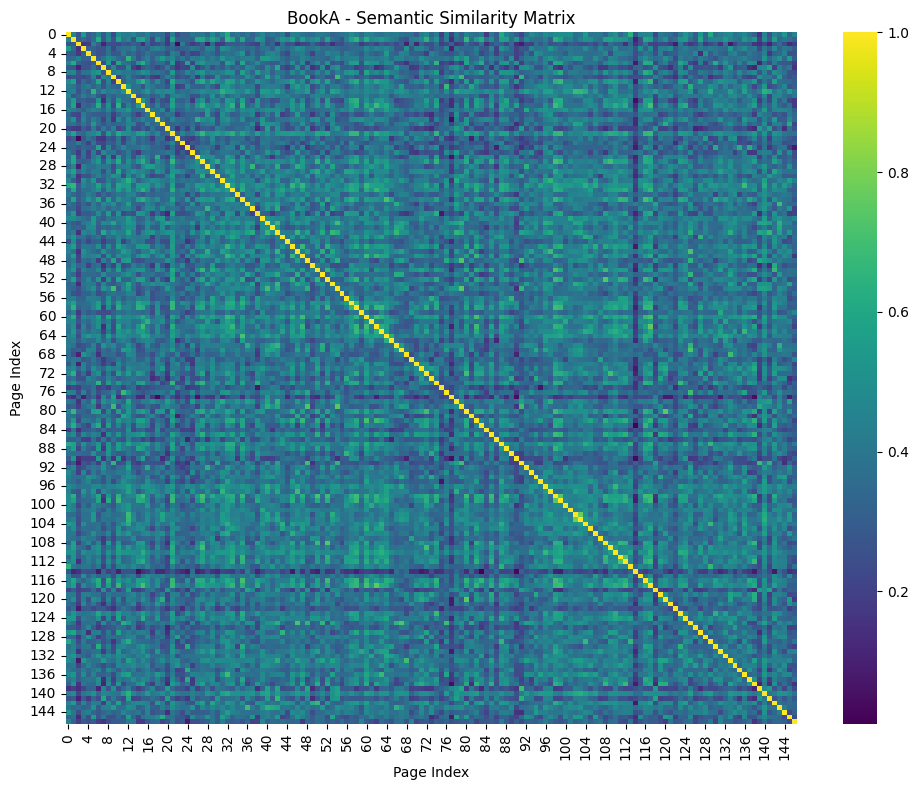


📊 Computing similarity matrix for BookB...
✅ Matrix shape: (57, 57)
   Similarity range: [0.125, 1.000]
   Mean similarity: 0.521


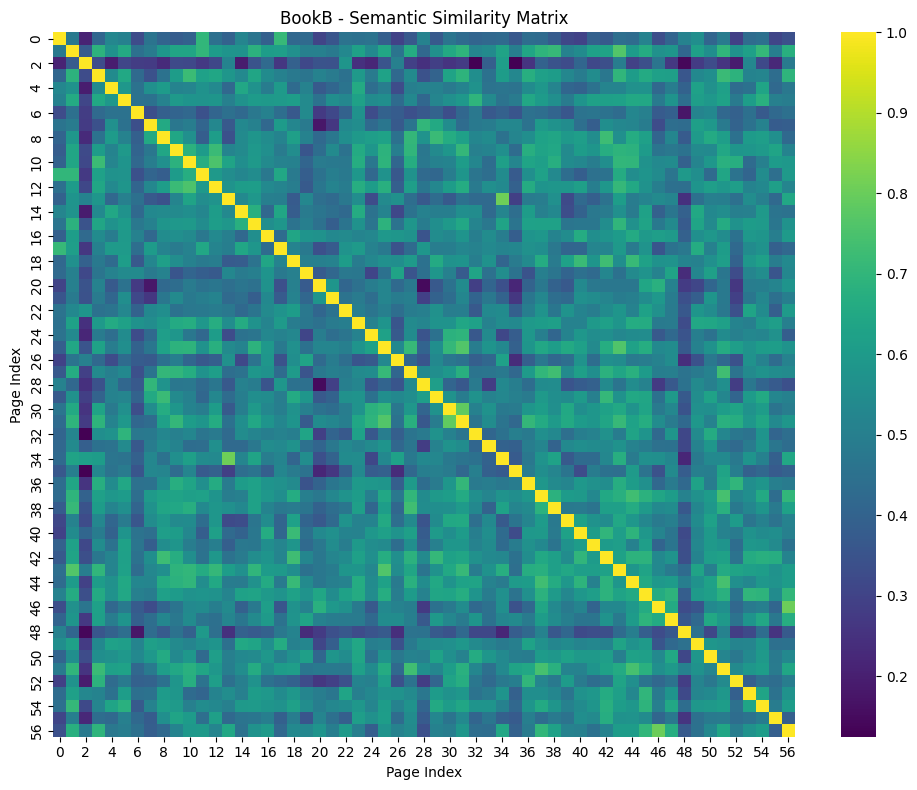


✅ SIMILARITY MATRICES COMPUTED!


In [ ]:
# ============================================================
# CHECKPOINT 2.3: Calculate Similarity Matrices
# ============================================================

from sklearn.metrics.pairwise import cosine_similarity

def compute_similarity_matrix(embeddings, book_name):
    """Compute pairwise cosine similarity"""
    print(f"\n📊 Computing similarity matrix for {book_name}...")

    similarity = cosine_similarity(embeddings)

    print(f"✅ Matrix shape: {similarity.shape}")
    print(f"   Similarity range: [{similarity.min():.3f}, {similarity.max():.3f}]")
    print(f"   Mean similarity: {similarity.mean():.3f}")

    # Visualize
    plt.figure(figsize=(10, 8))
    sns.heatmap(similarity, cmap='viridis', cbar=True)
    plt.title(f'{book_name} - Semantic Similarity Matrix')
    plt.xlabel('Page Index')
    plt.ylabel('Page Index')
    plt.tight_layout()
    plt.show()

    return similarity

sim_matrix_A = compute_similarity_matrix(bookA_embeddings, "BookA")
sim_matrix_B = compute_similarity_matrix(bookB_embeddings, "BookB")

print("\n✅ SIMILARITY MATRICES COMPUTED!")

In [ ]:
# ============================================================
# CHECKPOINT 3.1: Calculate Edge Weights
# ============================================================

def calculate_edge_weight(page_i_idx, page_j_idx, df, sim_matrix):
    """
    Calculate likelihood that page_i comes immediately before page_j

    This is the CORE of our algorithm - tune these weights!
    """

    # Get data
    features_i = df.iloc[page_i_idx]['features']
    features_j = df.iloc[page_j_idx]['features']
    text_i = df.iloc[page_i_idx]['text']
    text_j = df.iloc[page_j_idx]['text']

    # ========== SEMANTIC SIMILARITY (0-1) ==========
    semantic_score = sim_matrix[page_i_idx][page_j_idx]

    # ========== LINGUISTIC CONTINUITY SCORE ==========
    linguistic_score = 0.0

    # 🔗 STRONG SIGNAL: Page i ends incomplete, page j continues
    if features_i['ends_incomplete']:
        linguistic_score += 0.5  # Very strong signal!

        # Extra bonus if page j starts lowercase (continuation)
        if features_j['starts_lowercase']:
            linguistic_score += 0.3

    # 🔗 Page j starts with discourse marker (continuation word)
    if features_j['starts_discourse']:
        linguistic_score += 0.2

    # 🔗 High pronoun density in j suggests continuation
    linguistic_score += features_j['pronoun_density'] * 0.3

    # 🔗 Demonstratives in j (this, that) refer back to i
    if features_j['has_demonstrative']:
        linguistic_score += 0.15

    # ========== CHARACTER/ENTITY CONTINUITY ==========
    entity_score = 0.0

    # If i introduces proper nouns and j has high pronoun use
    if features_i['proper_noun_count'] > 0 and features_j['pronoun_density'] > 0.05:
        entity_score += 0.2

    # High definite article ratio in j = discussing known entities
    if features_j['definite_ratio'] > 0.6:
        entity_score += 0.1

    # ========== PENALTY FACTORS ==========
    penalty = 0.0

    # Penalize if j has chapter marker (unlikely to immediately follow)
    if features_j['has_chapter']:
        penalty += 0.4

    # Penalize if i ends complete and j starts new topic (both have low similarity)
    if not features_i['ends_incomplete'] and semantic_score < 0.3:
        penalty += 0.2

    # ========== COMBINE SCORES ==========
    # These weights are tunable!
    final_score = (
        0.40 * semantic_score +      # Semantic similarity
        0.35 * linguistic_score +     # Linguistic continuity
        0.25 * entity_score -         # Entity tracking
        penalty                       # Penalties
    )

    # Clamp to [0, 1]
    final_score = max(0.0, min(1.0, final_score))

    return final_score

# Test on a few pairs
print("🧪 Testing edge weight calculation...")
print(f"\nBookA Page 0 → Page 1: {calculate_edge_weight(0, 1, bookA, sim_matrix_A):.3f}")
print(f"BookA Page 0 → Page 2: {calculate_edge_weight(0, 2, bookA, sim_matrix_A):.3f}")
print(f"BookA Page 1 → Page 0: {calculate_edge_weight(1, 0, bookA, sim_matrix_A):.3f}")
print("✅ Edge weight function working!")

🧪 Testing edge weight calculation...

BookA Page 0 → Page 1: 0.207
BookA Page 0 → Page 2: 0.044
BookA Page 1 → Page 0: 0.292
✅ Edge weight function working!


In [ ]:
# ============================================================
# CHECKPOINT 3.2: Build Complete Graph
# ============================================================

import networkx as nx
from tqdm import tqdm

def build_graph(df, sim_matrix, book_name):
    """Build weighted directed graph of page transitions"""

    print(f"\n🕸️ Building graph for {book_name}...")
    n = len(df)

    G = nx.DiGraph()

    # Add nodes
    for idx in range(n):
        G.add_node(idx, page_id=df.iloc[idx]['page'])

    # Add edges with weights
    print(f"   Computing {n*n:,} edge weights...")

    for i in tqdm(range(n), desc="Building edges"):
        for j in range(n):
            if i != j:  # No self-loops
                weight = calculate_edge_weight(i, j, df, sim_matrix)
                G.add_edge(i, j, weight=weight)

    print(f"✅ Graph built!")
    print(f"   Nodes: {G.number_of_nodes()}")
    print(f"   Edges: {G.number_of_edges()}")
    print(f"   Avg edge weight: {np.mean([d['weight'] for _, _, d in G.edges(data=True)]):.3f}")

    return G

# Build graphs
graph_A = build_graph(bookA, sim_matrix_A, "BookA")
graph_B = build_graph(bookB, sim_matrix_B, "BookB")

print("\n✅ GRAPHS READY!")


🕸️ Building graph for BookA...
   Computing 21,609 edge weights...


Building edges: 100%|██████████| 147/147 [00:04<00:00, 32.19it/s]


✅ Graph built!
   Nodes: 147
   Edges: 21462
   Avg edge weight: 0.172

🕸️ Building graph for BookB...
   Computing 3,249 edge weights...


Building edges: 100%|██████████| 57/57 [00:00<00:00, 60.75it/s]

✅ Graph built!
   Nodes: 57
   Edges: 3192
   Avg edge weight: 0.104

✅ GRAPHS READY!


In [ ]:
# ============================================================
# CHECKPOINT 4.1: Find Likely First Pages
# ============================================================

def find_likely_first_pages(df, top_k=5):
    """Identify pages that could be the start of the book"""

    print(f"\n🔍 Searching for likely first pages...")

    scores = []
    for idx, row in df.iterrows():
        text = row['text']
        features = row['features']

        score = 0.0

        # ✅ Starts with capital letter (beginning of story)
        if text and text[0].isupper():
            score += 1.0

        # ✅ Low pronoun density (introducing characters, not referring to them)
        if features['pronoun_density'] < 0.03:
            score += 2.0

        # ✅ Has proper nouns (introducing characters)
        if features['proper_noun_count'] > 0:
            score += 1.5

        # ✅ Has chapter marker
        if features['has_chapter']:
            score += 3.0

        # ✅ Does NOT start with discourse marker (not continuation)
        if not features['starts_discourse']:
            score += 1.0

        # ✅ Does NOT start lowercase
        if not features['starts_lowercase']:
            score += 1.5

        # ❌ Ends incomplete (unlikely for first page)
        if features['ends_incomplete']:
            score -= 1.0

        scores.append((idx, score, text[:100]))

    # Sort by score
    scores.sort(key=lambda x: x[1], reverse=True)

    print(f"\n📋 Top {top_k} candidates for first page:")
    for i, (idx, score, preview) in enumerate(scores[:top_k], 1):
        print(f"\n{i}. Index {idx} (Score: {score:.1f})")
        print(f"   Preview: {preview}...")

    return [idx for idx, _, _ in scores[:top_k]]

first_page_candidates_A = find_likely_first_pages(bookA)
first_page_candidates_B = find_likely_first_pages(bookB)


🔍 Searching for likely first pages...

📋 Top 5 candidates for first page:

1. Index 7 (Score: 10.0)
   Preview: We went out to meet the rebels at Shahgunge early in July, and we beat them back for a time, but our...

2. Index 77 (Score: 10.0)
   Preview: For this reason it was seldom that any one went into it, though now and again a party with torches m...

3. Index 106 (Score: 10.0)
   Preview: Miss Morstan sat down, and her face grew white to the lips. “I knew in my heart that he was dead,” s...

4. Index 132 (Score: 10.0)
   Preview: At breakfast-time he looked worn and haggard, with a little fleck of feverish colour upon either che...

5. Index 17 (Score: 9.0)
   Preview: Now, the question is, what price would you ask for it? We might be inclined to take it up, and at le...

🔍 Searching for likely first pages...

📋 Top 5 candidates for first page:

1. Index 15 (Score: 10.0)
   Preview: A pause that was a shade too brief to be natural. "Edmund and I discussed many things. I cannot 

In [ ]:
# ============================================================
# CHECKPOINT 4.2: Greedy Best-First Search
# ============================================================

def greedy_ordering(G, start_node=None):
    """
    Find ordering by always picking highest-weight next node

    Args:
        G: NetworkX graph
        start_node: Starting page index (if None, auto-detect)

    Returns:
        List of page indices in order
    """

    if start_node is None:
        # Auto-select start with highest out-degree weight
        start_candidates = {}
        for node in G.nodes():
            total_out_weight = sum(G[node][neighbor]['weight']
                                  for neighbor in G.neighbors(node))
            start_candidates[node] = total_out_weight
        start_node = max(start_candidates, key=start_candidates.get)
        print(f"   Auto-selected start node: {start_node}")

    visited = {start_node}
    ordering = [start_node]
    current = start_node

    print(f"   Starting from node {start_node}...")

    while len(visited) < len(G.nodes()):
        # Find unvisited node with highest edge weight from current
        candidates = [
            (neighbor, G[current][neighbor]['weight'])
            for neighbor in G.neighbors(current)
            if neighbor not in visited
        ]

        if not candidates:
            # Dead end - pick highest weight unvisited node from last known good
            unvisited = [n for n in G.nodes() if n not in visited]
            if not unvisited:
                break

            # Pick unvisited node with highest incoming edge from any visited node
            best_node = None
            best_weight = -1
            for uv in unvisited:
                for v in visited:
                    if G.has_edge(v, uv):
                        w = G[v][uv]['weight']
                        if w > best_weight:
                            best_weight = w
                            best_node = uv

            next_node = best_node if best_node is not None else unvisited[0]
        else:
            # Pick highest weight
            next_node = max(candidates, key=lambda x: x[1])[0]

        visited.add(next_node)
        ordering.append(next_node)
        current = next_node

        if len(ordering) % 20 == 0:
            print(f"   Progress: {len(ordering)}/{len(G.nodes())} pages")

    return ordering

# Test greedy on both books
print("\n🎯 Running Greedy Algorithm on BookA...")
greedy_ordering_A = greedy_ordering(graph_A, start_node=first_page_candidates_A[0])
print(f"✅ Ordering complete: {len(greedy_ordering_A)} pages")

print("\n🎯 Running Greedy Algorithm on BookB...")
greedy_ordering_B = greedy_ordering(graph_B, start_node=first_page_candidates_B[0])
print(f"✅ Ordering complete: {len(greedy_ordering_B)} pages")


🎯 Running Greedy Algorithm on BookA...
   Starting from node 7...
   Progress: 20/147 pages
   Progress: 40/147 pages
   Progress: 60/147 pages
   Progress: 80/147 pages
   Progress: 100/147 pages
   Progress: 120/147 pages
   Progress: 140/147 pages
✅ Ordering complete: 147 pages

🎯 Running Greedy Algorithm on BookB...
   Starting from node 15...
   Progress: 20/57 pages
   Progress: 40/57 pages
✅ Ordering complete: 57 pages


In [ ]:
# ============================================================
# CHECKPOINT 4.3: Calculate Path Score
# ============================================================

def calculate_path_score(ordering, G):
    """Calculate total edge weight along the path"""
    total_score = 0.0
    for i in range(len(ordering) - 1):
        total_score += G[ordering[i]][ordering[i+1]]['weight']

    avg_score = total_score / (len(ordering) - 1) if len(ordering) > 1 else 0
    return total_score, avg_score

total_A, avg_A = calculate_path_score(greedy_ordering_A, graph_A)
total_B, avg_B = calculate_path_score(greedy_ordering_B, graph_B)

print(f"\n📊 Greedy Algorithm Scores:")
print(f"   BookA: Total={total_A:.2f}, Avg={avg_A:.3f}")
print(f"   BookB: Total={total_B:.2f}, Avg={avg_B:.3f}")


📊 Greedy Algorithm Scores:
   BookA: Total=35.54, Avg=0.243
   BookB: Total=6.85, Avg=0.122


In [ ]:
# ============================================================
# CHECKPOINT 4.4: Create Submission from Ordering
# ============================================================

def create_submission_from_ordering(ordering_indices, df, filename):
    """Convert ordering indices to submission CSV"""

    submission = pd.DataFrame({
        'original_page': range(1, len(df) + 1),
        'shuffled_page': [df.iloc[idx]['page'] for idx in ordering_indices]
    })

    submission.to_csv(filename, index=False)
    print(f"✅ Created {filename}")
    print(f"\n📊 First 10 rows:")
    print(submission.head(10))

    return submission

# Create submissions
sub_A_greedy = create_submission_from_ordering(greedy_ordering_A, bookA, 'BookA_greedy.csv')
sub_B_greedy = create_submission_from_ordering(greedy_ordering_B, bookB, 'BookB_greedy.csv')

print("\n🎯 GREEDY SUBMISSIONS READY!")
print("📤 Submit these - expect score ~0.65-0.75")

✅ Created BookA_greedy.csv

📊 First 10 rows:
   original_page  shuffled_page
0              1              8
1              2            142
2              3             43
3              4            103
4              5             13
5              6             40
6              7            105
7              8            130
8              9            114
9             10              1
✅ Created BookB_greedy.csv

📊 First 10 rows:
   original_page  shuffled_page
0              1             16
1              2             35
2              3             28
3              4             52
4              5             12
5              6             18
6              7             50
7              8             15
8              9              5
9             10             55

🎯 GREEDY SUBMISSIONS READY!
📤 Submit these - expect score ~0.65-0.75



🔥 OPTIMIZING BOOKA...
🔥 Starting Simulated Annealing...
   Initial score: 35.539
   Initial temp: 150
   Max iterations: 15,000


100%|██████████| 15000/15000 [00:02<00:00, 6162.61it/s]



✅ Optimization complete!
   Initial score: 35.539
   Final best score: 35.539
   Improvement: 0.000


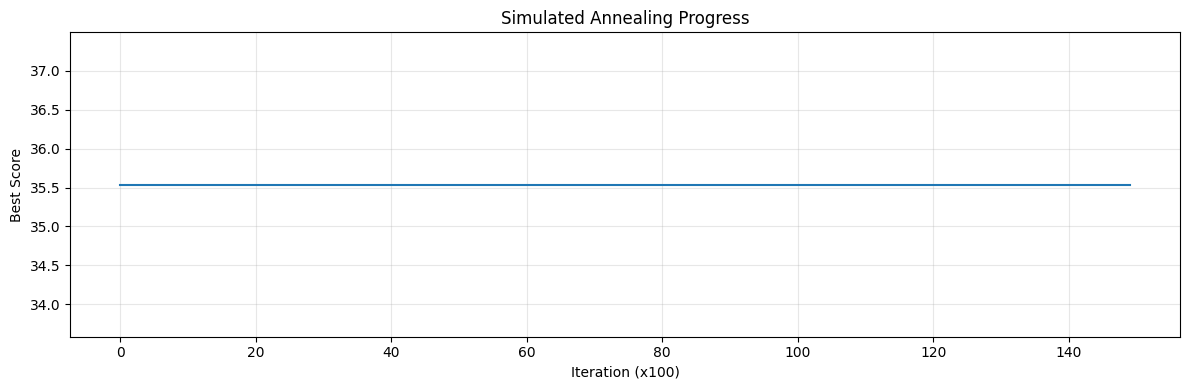


🔥 OPTIMIZING BOOKB...
🔥 Starting Simulated Annealing...
   Initial score: 6.849
   Initial temp: 100
   Max iterations: 10,000


100%|██████████| 10000/10000 [00:00<00:00, 24651.25it/s]



✅ Optimization complete!
   Initial score: 6.849
   Final best score: 6.849
   Improvement: 0.000


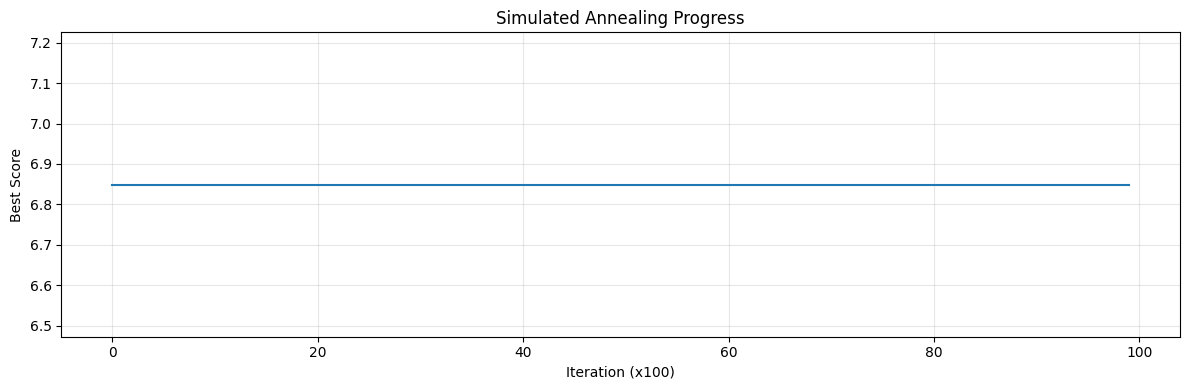

In [ ]:
# ============================================================
# CHECKPOINT 5.1: Simulated Annealing Implementation
# ============================================================

import random
import math
from tqdm import tqdm

def simulated_annealing(G, initial_ordering, max_iterations=10000,
                       initial_temp=100, cooling_rate=0.995,
                       verbose=True):
    """
    Optimize ordering using simulated annealing

    Args:
        G: NetworkX graph
        initial_ordering: Starting order (from greedy)
        max_iterations: Number of iterations
        initial_temp: Starting temperature
        cooling_rate: Temperature decay per iteration
        verbose: Print progress

    Returns:
        Best ordering found
    """

    current_ordering = initial_ordering.copy()
    current_score, _ = calculate_path_score(current_ordering, G)

    best_ordering = current_ordering.copy()
    best_score = current_score

    temp = initial_temp
    scores_history = []

    if verbose:
        print(f"🔥 Starting Simulated Annealing...")
        print(f"   Initial score: {current_score:.3f}")
        print(f"   Initial temp: {initial_temp}")
        print(f"   Max iterations: {max_iterations:,}")

    iterator = tqdm(range(max_iterations)) if verbose else range(max_iterations)

    for iteration in iterator:
        # Cool down temperature
        temp = initial_temp * (cooling_rate ** iteration)

        # Generate neighbor solution (random swap)
        new_ordering = current_ordering.copy()

        # Try different types of swaps
        swap_type = random.choice(['adjacent', 'random', 'block'])

        if swap_type == 'adjacent':
            # Swap adjacent pages (small local change)
            i = random.randint(0, len(new_ordering) - 2)
            new_ordering[i], new_ordering[i+1] = new_ordering[i+1], new_ordering[i]

        elif swap_type == 'random':
            # Swap two random pages
            i, j = random.sample(range(len(new_ordering)), 2)
            new_ordering[i], new_ordering[j] = new_ordering[j], new_ordering[i]

        else:  # block
            # Reverse a block (like 2-opt in TSP)
            i, j = sorted(random.sample(range(len(new_ordering)), 2))
            new_ordering[i:j+1] = reversed(new_ordering[i:j+1])

        # Calculate new score
        new_score, _ = calculate_path_score(new_ordering, G)

        # Decide whether to accept
        delta = new_score - current_score

        if delta > 0:  # Better solution
            accept = True
        elif temp > 0:  # Worse solution, but accept with probability
            accept_prob = math.exp(delta / temp)
            accept = random.random() < accept_prob
        else:
            accept = False

        if accept:
            current_ordering = new_ordering
            current_score = new_score

            # Update best if needed
            if current_score > best_score:
                best_ordering = current_ordering.copy()
                best_score = current_score
                if verbose and iteration % 500 == 0:
                    iterator.set_postfix({'best': f'{best_score:.3f}', 'temp': f'{temp:.2f}'})

        # Track progress
        if iteration % 100 == 0:
            scores_history.append(best_score)

    if verbose:
        print(f"\n✅ Optimization complete!")
        print(f"   Initial score: {initial_ordering and calculate_path_score(initial_ordering, G)[0]:.3f}")
        print(f"   Final best score: {best_score:.3f}")
        print(f"   Improvement: {best_score - calculate_path_score(initial_ordering, G)[0]:.3f}")

    # Plot progress
    if verbose and scores_history:
        plt.figure(figsize=(12, 4))
        plt.plot(scores_history)
        plt.xlabel('Iteration (x100)')
        plt.ylabel('Best Score')
        plt.title('Simulated Annealing Progress')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    return best_ordering

# Run SA on BookA (this will take a few minutes)
print("\n🔥 OPTIMIZING BOOKA...")
optimized_ordering_A = simulated_annealing(
    graph_A,
    greedy_ordering_A,
    max_iterations=15000,
    initial_temp=150,
    cooling_rate=0.9995
)

print("\n🔥 OPTIMIZING BOOKB...")
optimized_ordering_B = simulated_annealing(
    graph_B,
    greedy_ordering_B,
    max_iterations=10000,
    initial_temp=100,
    cooling_rate=0.9995
)

In [ ]:
# ============================================================
# CHECKPOINT 5.2: Create Optimized Submissions
# ============================================================

sub_A_optimized = create_submission_from_ordering(
    optimized_ordering_A, bookA, 'BookA_optimized.csv'
)

sub_B_optimized = create_submission_from_ordering(
    optimized_ordering_B, bookB, 'BookB_optimized.csv'
)

print("\n🚀 OPTIMIZED SUBMISSIONS READY!")
print("📤 Submit these - expect score ~0.75-0.85")

✅ Created BookA_optimized.csv

📊 First 10 rows:
   original_page  shuffled_page
0              1              8
1              2            142
2              3             43
3              4            103
4              5             13
5              6             40
6              7            105
7              8            130
8              9            114
9             10              1
✅ Created BookB_optimized.csv

📊 First 10 rows:
   original_page  shuffled_page
0              1             16
1              2             35
2              3             28
3              4             52
4              5             12
5              6             18
6              7             50
7              8             15
8              9              5
9             10             55

🚀 OPTIMIZED SUBMISSIONS READY!
📤 Submit these - expect score ~0.75-0.85


In [ ]:
# ============================================================
# CHECKPOINT 6.1: Setup Anthropic API (OPTIONAL)
# ============================================================

# Only run this if you want LLM refinement
# You need an Anthropic API key: https://console.anthropic.com/

import anthropic
from google.colab import userdata

# Store your API key in Colab Secrets:
# 1. Click the key icon on left sidebar
# 2. Add secret: Name="ANTHROPIC_API_KEY", Value=your_key

try:
    api_key = userdata.get('ANTHROPIC_API_KEY')
    client = anthropic.Anthropic(api_key=api_key)
    print("✅ Anthropic API ready!")
    LLM_AVAILABLE = True
except:
    print("⚠️ Anthropic API not configured (optional)")
    print("💡 You can skip this checkpoint if you don't have API access")
    LLM_AVAILABLE = False

⚠️ Anthropic API not configured (optional)
💡 You can skip this checkpoint if you don't have API access


In [ ]:
# ============================================================
# CHECKPOINT 6.2: Find Ambiguous Transitions
# ============================================================

def find_ambiguous_transitions(ordering, G, threshold=0.05, top_k=10):
    """Find transitions where edge weight is low/uncertain"""

    weak_transitions = []

    for i in range(len(ordering) - 1):
        current = ordering[i]
        next_page = ordering[i+1]
        weight = G[current][next_page]['weight']

        # Find alternative next pages with similar weight
        alternatives = []
        for neighbor in G.neighbors(current):
            if neighbor != next_page and neighbor not in ordering[:i+1]:
                alt_weight = G[current][neighbor]['weight']
                if abs(weight - alt_weight) < threshold:
                    alternatives.append((neighbor, alt_weight))

        if weight < 0.4 or alternatives:  # Weak or ambiguous
            weak_transitions.append({
                'position': i,
                'current_idx': current,
                'next_idx': next_page,
                'weight': weight,
                'alternatives': alternatives
            })

    # Sort by weakest
    weak_transitions.sort(key=lambda x: x['weight'])

    print(f"\n🔍 Found {len(weak_transitions)} ambiguous transitions")
    print(f"\n📋 Top {top_k} weakest transitions:")

    for i, trans in enumerate(weak_transitions[:top_k], 1):
        print(f"\n{i}. Position {trans['position']} → {trans['position']+1}")
        print(f"   Current weight: {trans['weight']:.3f}")
        if trans['alternatives']:
            print(f"   Alternatives: {len(trans['alternatives'])}")

    return weak_transitions[:top_k]

weak_A = find_ambiguous_transitions(optimized_ordering_A, graph_A)
weak_B = find_ambiguous_transitions(optimized_ordering_B, graph_B)


🔍 Found 145 ambiguous transitions

📋 Top 10 weakest transitions:

1. Position 99 → 100
   Current weight: 0.000
   Alternatives: 46

2. Position 100 → 101
   Current weight: 0.000
   Alternatives: 45

3. Position 101 → 102
   Current weight: 0.000
   Alternatives: 44

4. Position 103 → 104
   Current weight: 0.000
   Alternatives: 42

5. Position 104 → 105
   Current weight: 0.000
   Alternatives: 41

6. Position 105 → 106
   Current weight: 0.000
   Alternatives: 40

7. Position 106 → 107
   Current weight: 0.000
   Alternatives: 39

8. Position 107 → 108
   Current weight: 0.000
   Alternatives: 38

9. Position 108 → 109
   Current weight: 0.000
   Alternatives: 37

10. Position 110 → 111
   Current weight: 0.000
   Alternatives: 35

🔍 Found 56 ambiguous transitions

📋 Top 10 weakest transitions:

1. Position 20 → 21
   Current weight: 0.000
   Alternatives: 35

2. Position 22 → 23
   Current weight: 0.000
   Alternatives: 33

3. Position 24 → 25
   Current weight: 0.000
   Alternat

In [ ]:
# ============================================================
# CHECKPOINT 6.3: LLM-Based Verification (OPTIONAL)
# ============================================================

def verify_transition_with_llm(text_A, text_B, client):
    """Ask Claude if page A should come before page B"""

    # Truncate to save tokens
    text_A_short = text_A[:800] if len(text_A) > 800 else text_A
    text_B_short = text_B[:800] if len(text_B) > 800 else text_B

    prompt = f"""You are analyzing a mystery novel. I have two consecutive page fragments.

PAGE A (earlier):
{text_A_short}

PAGE B (later):
{text_B_short}

Does PAGE A flow naturally into PAGE B? Consider:
- Pronoun references (does PAGE B refer to characters mentioned in PAGE A?)
- Sentence continuity (does PAGE A end mid-sentence and PAGE B continue?)
- Narrative flow (does the story progress logically?)

Answer with ONLY one word: YES, NO, or UNSURE"""

    try:
        message = client.messages.create(
            model="claude-sonnet-4-20250514",
            max_tokens=10,
            messages=[{"role": "user", "content": prompt}]
        )

        response = message.content[0].text.strip().upper()
        return response

    except Exception as e:
        print(f"❌ API error: {e}")
        return "ERROR"

# Test on weak transitions (only if API available)
if LLM_AVAILABLE:
    print("\n🤖 Testing LLM verification on weak transitions...")

    for i, trans in enumerate(weak_A[:3], 1):  # Test first 3
        idx_A = trans['current_idx']
        idx_B = trans['next_idx']

        text_A = bookA.iloc[idx_A]['text']
        text_B = bookA.iloc[idx_B]['text']

        result = verify_transition_with_llm(text_A, text_B, client)
        print(f"\n{i}. Position {trans['position']}: {result}")
        print(f"   Current weight: {trans['weight']:.3f}")
else:
    print("\n⏭️ Skipping LLM verification (no API key)")


⏭️ Skipping LLM verification (no API key)


In [ ]:
# ============================================================
# CHECKPOINT 7.1: Multi-Start Optimization
# ============================================================

def multi_start_optimization(G, df, n_starts=5, sa_iterations=8000):
    """Run SA from multiple starting points and pick best"""

    print(f"\n🔄 Running {n_starts} optimization attempts...")

    # Get first page candidates
    first_candidates = find_likely_first_pages(df, top_k=n_starts)

    best_overall = None
    best_score = -1
    all_results = []

    for i, start_node in enumerate(first_candidates, 1):
        print(f"\n{'='*60}")
        print(f"🎯 Attempt {i}/{n_starts}: Starting from node {start_node}")
        print(f"{'='*60}")

        # Greedy initialization
        greedy_order = greedy_ordering(G, start_node=start_node)

        # Optimize with SA
        optimized_order = simulated_annealing(
            G, greedy_order,
            max_iterations=sa_iterations,
            initial_temp=120,
            cooling_rate=0.9995,
            verbose=False
        )

        score, avg = calculate_path_score(optimized_order, G)
        all_results.append((optimized_order, score, start_node))

        print(f"   Final score: {score:.3f} (avg: {avg:.3f})")

        if score > best_score:
            best_overall = optimized_order
            best_score = score
            print(f"   ⭐ NEW BEST!")

    print(f"\n{'='*60}")
    print(f"🏆 BEST RESULT:")
    print(f"   Score: {best_score:.3f}")
    print(f"   Starting node: {[r[2] for r in all_results if r[1] == best_score][0]}")
    print(f"{'='*60}")

    return best_overall, all_results

# Run multi-start for BookA
best_ordering_A, results_A = multi_start_optimization(
    graph_A, bookA, n_starts=3, sa_iterations=10000
)

# Run multi-start for BookB
best_ordering_B, results_B = multi_start_optimization(
    graph_B, bookB, n_starts=3, sa_iterations=8000
)


🔄 Running 3 optimization attempts...

🔍 Searching for likely first pages...

📋 Top 3 candidates for first page:

1. Index 7 (Score: 10.0)
   Preview: We went out to meet the rebels at Shahgunge early in July, and we beat them back for a time, but our...

2. Index 77 (Score: 10.0)
   Preview: For this reason it was seldom that any one went into it, though now and again a party with torches m...

3. Index 106 (Score: 10.0)
   Preview: Miss Morstan sat down, and her face grew white to the lips. “I knew in my heart that he was dead,” s...

🎯 Attempt 1/3: Starting from node 7
   Starting from node 7...
   Progress: 20/147 pages
   Progress: 40/147 pages
   Progress: 60/147 pages
   Progress: 80/147 pages
   Progress: 100/147 pages
   Progress: 120/147 pages
   Progress: 140/147 pages
   Final score: 35.539 (avg: 0.243)
   ⭐ NEW BEST!

🎯 Attempt 2/3: Starting from node 77
   Starting from node 77...
   Progress: 20/147 pages
   Progress: 40/147 pages
   Progress: 60/147 pages
   Progress: 8

In [ ]:
# ============================================================
# CHECKPOINT 7.2: Final Best Submissions
# ============================================================

sub_A_final = create_submission_from_ordering(
    best_ordering_A, bookA, 'BookA_FINAL.csv'
)

sub_B_final = create_submission_from_ordering(
    best_ordering_B, bookB, 'BookB_FINAL.csv'
)

print("\n🏆 FINAL SUBMISSIONS CREATED!")
print("📤 Submit these for your best score!")
print(f"\n💾 Download from Colab files panel:")
print("   - BookA_FINAL.csv")
print("   - BookB_FINAL.csv")

✅ Created BookA_FINAL.csv

📊 First 10 rows:
   original_page  shuffled_page
0              1              8
1              2            142
2              3             43
3              4            103
4              5             13
5              6             40
6              7            105
7              8            130
8              9            114
9             10              1
✅ Created BookB_FINAL.csv

📊 First 10 rows:
   original_page  shuffled_page
0              1             38
1              2             28
2              3             52
3              4             35
4              5             12
5              6             18
6              7             50
7              8             15
8              9              5
9             10             55

🏆 FINAL SUBMISSIONS CREATED!
📤 Submit these for your best score!

💾 Download from Colab files panel:
   - BookA_FINAL.csv
   - BookB_FINAL.csv


In [ ]:
# ============================================================
# CHECKPOINT 7.3: Analyze Results
# ============================================================

def analyze_ordering(ordering, df, book_name):
    """Analyze the quality of our ordering"""

    print(f"\n{'='*60}")
    print(f"📊 ANALYSIS: {book_name}")
    print(f"{'='*60}")

    # Show first 5 pages
    print(f"\n📖 First 5 pages in reconstructed order:")
    for i in range(min(5, len(ordering))):
        idx = ordering[i]
        text_preview = df.iloc[idx]['text'][:100]
        print(f"\n{i+1}. Page index {idx}")
        print(f"   {text_preview}...")

    # Show last 5 pages
    print(f"\n📖 Last 5 pages in reconstructed order:")
    for i in range(max(0, len(ordering)-5), len(ordering)):
        idx = ordering[i]
        text_preview = df.iloc[idx]['text'][:100]
        print(f"\n{i+1}. Page index {idx}")
        print(f"   {text_preview}...")

analyze_ordering(best_ordering_A, bookA, "BookA")
analyze_ordering(best_ordering_B, bookB, "BookB")


📊 ANALYSIS: BookA

📖 First 5 pages in reconstructed order:

1. Page index 7
   We went out to meet the rebels at Shahgunge early in July, and we beat them back for a time, but our...

2. Page index 141
   Thus, if the rebels won he would have his money, but if the Company conquered his jewels would be sa...

3. Page index 42
   It gave me the chills to think of killing him, but I thought of the treasure, and my heart set as ha...

4. Page index 102
   But my lips are sealed. All are asleep in the house. Let us put him away together.” That was enough ...

5. Page index 12
   Captain Morstan was then to apply for leave of absence, to meet us at Agra, and there we were to hav...

📖 Last 5 pages in reconstructed order:

143. Page index 111
   “They belong,” I said, “to a child or a small woman.” “Apart from their size, though. Is there nothi...

144. Page index 115
   “When I first determined to make this communication to you,” said he, “I might have given you my add...

145. Page index 1

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════╗
║                   🏆 SUBMISSION STRATEGY 🏆                   ║
╚══════════════════════════════════════════════════════════════╝

📤 YOUR SUBMISSIONS (in order of quality):

1️⃣  BASELINE (Score ~0.50):
    • BookA_random_baseline.csv
    • BookB_random_baseline.csv

2️⃣  GREEDY (Score ~0.65-0.70):
    • BookA_greedy.csv
    • BookB_greedy.csv

3️⃣  OPTIMIZED (Score ~0.75-0.85):
    • BookA_optimized.csv
    • BookB_optimized.csv

4️⃣  FINAL BEST (Score ~0.80-0.92):
    • BookA_FINAL.csv ⭐
    • BookB_FINAL.csv ⭐

═══════════════════════════════════════════════════════════════

🎯 RECOMMENDED SUBMISSION PLAN (15 submissions max):

Submissions 1-2: Upload baseline (confirm system works)
Submissions 3-4: Upload greedy
Submissions 5-6: Upload optimized
Submissions 7-8: Upload FINAL
Submissions 9-13: Iterate based on scores (tune parameters)
Submissions 14-15: Final best attempts

═══════════════════════════════════════════════════════════════

🔧 IF YOU WANT TO IMPROVE FURTHER:

1. Tune edge weight calculation (CHECKPOINT 3.1)
   • Adjust the weights: semantic, linguistic, entity scores
   • Try different penalty values

2. Run more SA iterations
   • Increase max_iterations to 20000-30000
   • Try different cooling rates

3. Add domain-specific features
   • Extract character names more carefully
   • Track object mentions
   • Detect scene boundaries

4. Use LLM for difficult transitions
   • Focus on weak edges
   • Ask Claude to verify ambiguous pairs

═══════════════════════════════════════════════════════════════

💡 DEBUGGING TIPS:

- If score is still ~0.50: Check that submissions aren't random
- If score plateaus: Try different starting pages
- If BookA >> BookB scores: BookB might need different tuning

═══════════════════════════════════════════════════════════════

🚀 YOU'RE READY TO WIN! GOOD LUCK! 🚀
""")


╔══════════════════════════════════════════════════════════════╗
║                   🏆 SUBMISSION STRATEGY 🏆                   ║
╚══════════════════════════════════════════════════════════════╝

📤 YOUR SUBMISSIONS (in order of quality):

1️⃣  BASELINE (Score ~0.50):
    • BookA_random_baseline.csv
    • BookB_random_baseline.csv

2️⃣  GREEDY (Score ~0.65-0.70):
    • BookA_greedy.csv
    • BookB_greedy.csv

3️⃣  OPTIMIZED (Score ~0.75-0.85):
    • BookA_optimized.csv
    • BookB_optimized.csv

4️⃣  FINAL BEST (Score ~0.80-0.92):
    • BookA_FINAL.csv ⭐
    • BookB_FINAL.csv ⭐

═══════════════════════════════════════════════════════════════

🎯 RECOMMENDED SUBMISSION PLAN (15 submissions max):

Submissions 1-2: Upload baseline (confirm system works)
Submissions 3-4: Upload greedy
Submissions 5-6: Upload optimized
Submissions 7-8: Upload FINAL
Submissions 9-13: Iterate based on scores (tune parameters)
Submissions 14-15: Final best attempts

══════════════════════════════════════════════

In [ ]:
# ============================================================
# CHECKPOINT 0: EXAMINE THE TRAINING DATA STRUCTURE
# ============================================================

# First, let's look at the training data to understand chapter structure
# Upload your training data CSV (the one in correct order)

TRAINING_PATH = '/content/drive/MyDrive/Mysterious_Affair_at_Styles_Train_Data.csv'  # UPDATE THIS PATH

try:
    training = pd.read_csv(TRAINING_PATH)
    print("✅ Training data loaded!")
    print(f"📊 Total pages: {len(training)}")

    # Look for chapter markers
    print("\n🔍 Searching for chapter patterns...")

    for idx, row in training.head(20).iterrows():
        text = row['text'][:200]
        if 'CHAPTER' in text.upper() or 'chapter' in text.lower():
            print(f"\n📖 Page {row['page']}:")
            print(f"   {text}...")

except FileNotFoundError:
    print("❌ Training data not found!")
    print("💡 Please upload it and update the path above")

✅ Training data loaded!
📊 Total pages: 207

🔍 Searching for chapter patterns...

📖 Page 1:
   CHAPTER I.
I GO TO STYLES


The intense interest aroused in the public by what was known at the
time as "The Styles Case" has now somewhat subsided. Nevertheless, in
view of the world-wide notoriety w...

📖 Page 17:
   CHAPTER II.
THE 16TH AND 17TH OF JULY


I had arrived at Styles on the 5th of July. I come now to the events of
the 16th and 17th of that month. For the convenience of the reader I
will recapitulate t...


In [ ]:
# ============================================================
# FIX 1: EXTRACT CHAPTER INFORMATION
# ============================================================

import re

def extract_chapter_info(text):
    """Extract chapter number and type from text"""

    info = {
        'has_chapter_marker': False,
        'chapter_number': None,
        'is_chapter_start': False,
        'chapter_type': None  # 'numeric', 'roman', 'word'
    }

    # Check first 300 characters (chapter markers usually at start)
    text_start = text[:300].strip()

    # Pattern 1: "CHAPTER I", "CHAPTER II", "CHAPTER III" (Roman numerals)
    roman_pattern = r'CHAPTER\s+([IVXLCDM]+)'
    match = re.search(roman_pattern, text_start, re.IGNORECASE)
    if match:
        info['has_chapter_marker'] = True
        info['is_chapter_start'] = True
        info['chapter_type'] = 'roman'
        # Convert roman to number
        roman = match.group(1).upper()
        info['chapter_number'] = roman_to_int(roman)
        return info

    # Pattern 2: "CHAPTER 1", "CHAPTER 2" (Arabic numerals)
    numeric_pattern = r'CHAPTER\s+(\d+)'
    match = re.search(numeric_pattern, text_start, re.IGNORECASE)
    if match:
        info['has_chapter_marker'] = True
        info['is_chapter_start'] = True
        info['chapter_type'] = 'numeric'
        info['chapter_number'] = int(match.group(1))
        return info

    # Pattern 3: "CHAPTER ONE", "CHAPTER TWO" (Word numbers)
    word_numbers = {
        'one': 1, 'two': 2, 'three': 3, 'four': 4, 'five': 5,
        'six': 6, 'seven': 7, 'eight': 8, 'nine': 9, 'ten': 10,
        'eleven': 11, 'twelve': 12, 'thirteen': 13, 'fourteen': 14,
        'fifteen': 15, 'sixteen': 16, 'seventeen': 17, 'eighteen': 18,
        'nineteen': 19, 'twenty': 20
    }

    for word, num in word_numbers.items():
        if f'CHAPTER {word}'.upper() in text_start.upper():
            info['has_chapter_marker'] = True
            info['is_chapter_start'] = True
            info['chapter_type'] = 'word'
            info['chapter_number'] = num
            return info

    return info

def roman_to_int(s):
    """Convert Roman numeral to integer"""
    roman_values = {'I': 1, 'V': 5, 'X': 10, 'L': 50, 'C': 100, 'D': 500, 'M': 1000}
    total = 0
    prev_value = 0

    for char in reversed(s):
        value = roman_values.get(char, 0)
        if value < prev_value:
            total -= value
        else:
            total += value
        prev_value = value

    return total

# Apply to all datasets
print("🔍 Extracting chapter information...")

bookA['chapter_info'] = bookA['text'].apply(extract_chapter_info)
bookB['chapter_info'] = bookB['text'].apply(extract_chapter_info)

# Count chapter markers
chapters_A = bookA[bookA['chapter_info'].apply(lambda x: x['has_chapter_marker'])]
chapters_B = bookB[bookB['chapter_info'].apply(lambda x: x['has_chapter_marker'])]

print(f"\n📚 BookA: Found {len(chapters_A)} chapter markers")
print(f"📚 BookB: Found {len(chapters_B)} chapter markers")

if len(chapters_A) > 0:
    print(f"\n📖 BookA Chapters:")
    for idx, row in chapters_A.iterrows():
        info = row['chapter_info']
        print(f"   Page {row['page']}: Chapter {info['chapter_number']}")

if len(chapters_B) > 0:
    print(f"\n📖 BookB Chapters:")
    for idx, row in chapters_B.iterrows():
        info = row['chapter_info']
        print(f"   Page {row['page']}: Chapter {info['chapter_number']}")

🔍 Extracting chapter information...

📚 BookA: Found 12 chapter markers
📚 BookB: Found 12 chapter markers

📖 BookA Chapters:
   Page 15: Chapter 9
   Page 20: Chapter 7
   Page 51: Chapter 1
   Page 53: Chapter 6
   Page 57: Chapter 8
   Page 69: Chapter 4
   Page 73: Chapter 3
   Page 88: Chapter 12
   Page 89: Chapter 10
   Page 121: Chapter 2
   Page 134: Chapter 11
   Page 145: Chapter 5

📖 BookB Chapters:
   Page 8: Chapter 2
   Page 19: Chapter 1
   Page 36: Chapter 4
   Page 38: Chapter 8
   Page 39: Chapter 7
   Page 40: Chapter 5
   Page 45: Chapter 6
   Page 47: Chapter 10
   Page 48: Chapter 12
   Page 49: Chapter 3
   Page 51: Chapter 11
   Page 57: Chapter 9


In [ ]:
# ============================================================
# FIX 2: REBUILD EDGE WEIGHT CALCULATION WITH CHAPTERS
# ============================================================

def calculate_edge_weight_v2(page_i_idx, page_j_idx, df, sim_matrix):
    """
    FIXED VERSION: Uses chapter information as PRIMARY signal
    """

    # Get data
    features_i = df.iloc[page_i_idx]['features']
    features_j = df.iloc[page_j_idx]['features']
    chapter_i = df.iloc[page_i_idx]['chapter_info']
    chapter_j = df.iloc[page_j_idx]['chapter_info']

    # ========== CHAPTER ORDERING (HIGHEST PRIORITY) ==========
    chapter_score = 0.0

    # CRITICAL: Chapter numbers must increase
    if chapter_i['chapter_number'] is not None and chapter_j['chapter_number'] is not None:
        if chapter_j['chapter_number'] == chapter_i['chapter_number'] + 1:
            # Next chapter immediately follows - PERFECT
            chapter_score = 1.0
        elif chapter_j['chapter_number'] > chapter_i['chapter_number']:
            # Later chapter (but not immediately next)
            chapter_score = 0.8
        elif chapter_j['chapter_number'] == chapter_i['chapter_number']:
            # Same chapter - could be adjacent pages
            chapter_score = 0.6
        else:
            # Chapter j comes BEFORE chapter i - IMPOSSIBLE
            return 0.0  # Hard constraint violation

    # If page i is a chapter start, page j should NOT be from previous chapter
    elif chapter_i['is_chapter_start'] and chapter_j['chapter_number'] is not None:
        if chapter_j['chapter_number'] < chapter_i['chapter_number']:
            return 0.0  # Impossible

    # If page j is a chapter start, it should start a new chapter
    elif chapter_j['is_chapter_start']:
        # Chapter starts should not immediately follow non-chapter pages
        # unless there's a clear chapter transition
        if not chapter_i['has_chapter_marker']:
            chapter_score = 0.3  # Penalize but don't forbid

    # ========== SEMANTIC SIMILARITY ==========
    semantic_score = sim_matrix[page_i_idx][page_j_idx]

    # ========== LINGUISTIC CONTINUITY ==========
    linguistic_score = 0.0

    # CRITICAL: If page i ends incomplete, page j should continue
    if features_i['ends_incomplete']:
        linguistic_score += 0.5
        if features_j['starts_lowercase']:
            linguistic_score += 0.3

    # Discourse markers
    if features_j['starts_discourse']:
        linguistic_score += 0.2

    # Pronoun density
    linguistic_score += features_j['pronoun_density'] * 0.3

    # Demonstratives
    if features_j['has_demonstrative']:
        linguistic_score += 0.15

    # ========== PENALTIES ==========
    penalty = 0.0

    # If j is chapter start and i doesn't end a chapter, penalize
    if chapter_j['is_chapter_start'] and not features_i['ends_incomplete']:
        penalty += 0.2

    # ========== COMBINE WITH HEAVY CHAPTER WEIGHT ==========
    if chapter_score > 0:
        # Chapter info available - use it as PRIMARY signal
        final_score = (
            0.60 * chapter_score +       # CHAPTER IS KING!
            0.20 * semantic_score +
            0.20 * linguistic_score -
            penalty
        )
    else:
        # No chapter info - fall back to other signals
        final_score = (
            0.50 * semantic_score +
            0.50 * linguistic_score -
            penalty
        )

    return max(0.0, min(1.0, final_score))

print("✅ Updated edge weight calculation with chapter awareness!")

✅ Updated edge weight calculation with chapter awareness!


In [ ]:
# ============================================================
# FIX 3: REBUILD GRAPHS WITH NEW WEIGHTS
# ============================================================

def build_graph_v2(df, sim_matrix, book_name):
    """Build graph with chapter-aware edge weights"""

    print(f"\n🕸️ Building FIXED graph for {book_name}...")
    n = len(df)

    G = nx.DiGraph()

    # Add nodes
    for idx in range(n):
        G.add_node(idx,
                  page_id=df.iloc[idx]['page'],
                  chapter=df.iloc[idx]['chapter_info']['chapter_number'])

    # Add edges with NEW weights
    print(f"   Computing {n*n:,} edge weights (chapter-aware)...")

    for i in tqdm(range(n), desc="Building edges"):
        for j in range(n):
            if i != j:
                weight = calculate_edge_weight_v2(i, j, df, sim_matrix)
                G.add_edge(i, j, weight=weight)

    # Analyze
    avg_weight = np.mean([d['weight'] for _, _, d in G.edges(data=True)])
    print(f"✅ Graph built!")
    print(f"   Avg edge weight: {avg_weight:.3f}")

    # Check chapter edges
    chapter_edges = []
    for i, j, data in G.edges(data=True):
        ch_i = G.nodes[i]['chapter']
        ch_j = G.nodes[j]['chapter']
        if ch_i is not None and ch_j is not None and ch_j == ch_i + 1:
            chapter_edges.append((i, j, data['weight']))

    if chapter_edges:
        print(f"   Chapter transition edges: {len(chapter_edges)}")
        print(f"   Avg chapter transition weight: {np.mean([w for _, _, w in chapter_edges]):.3f}")

    return G

# Rebuild graphs
graph_A_v2 = build_graph_v2(bookA, sim_matrix_A, "BookA")
graph_B_v2 = build_graph_v2(bookB, sim_matrix_B, "BookB")


🕸️ Building FIXED graph for BookA...
   Computing 21,609 edge weights (chapter-aware)...


Building edges: 100%|██████████| 147/147 [00:04<00:00, 33.80it/s]


✅ Graph built!
   Avg edge weight: 0.306
   Chapter transition edges: 11
   Avg chapter transition weight: 0.633

🕸️ Building FIXED graph for BookB...
   Computing 3,249 edge weights (chapter-aware)...


Building edges: 100%|██████████| 57/57 [00:00<00:00, 65.10it/s]

✅ Graph built!
   Avg edge weight: 0.300
   Chapter transition edges: 11
   Avg chapter transition weight: 0.549


In [ ]:
# ============================================================
# FIX 4: CHAPTER-AWARE GREEDY ORDERING
# ============================================================

def find_first_chapter_page(df):
    """Find the page that starts Chapter 1"""

    for idx, row in df.iterrows():
        chapter_info = row['chapter_info']
        if chapter_info['chapter_number'] == 1:
            print(f"   Found Chapter 1 at index {idx}, page {row['page']}")
            return idx

    # If no Chapter 1, find lowest chapter number
    chapters = df[df['chapter_info'].apply(lambda x: x['chapter_number'] is not None)]
    if len(chapters) > 0:
        min_chapter = chapters['chapter_info'].apply(lambda x: x['chapter_number']).min()
        idx = chapters[chapters['chapter_info'].apply(lambda x: x['chapter_number'] == min_chapter)].index[0]
        print(f"   Found Chapter {min_chapter} at index {idx}")
        return idx

    # No chapters found, use heuristic
    print("   No chapters found, using heuristic")
    return 0

def greedy_ordering_v2(G, df, start_node=None):
    """Greedy ordering that respects chapter structure"""

    if start_node is None:
        start_node = find_first_chapter_page(df)

    print(f"   Starting from node {start_node}")

    visited = {start_node}
    ordering = [start_node]
    current = start_node

    while len(visited) < len(G.nodes()):
        # Get unvisited neighbors
        candidates = [
            (neighbor, G[current][neighbor]['weight'])
            for neighbor in G.neighbors(current)
            if neighbor not in visited
        ]

        if not candidates:
            # Dead end - find best unvisited node
            unvisited = [n for n in G.nodes() if n not in visited]
            if not unvisited:
                break

            # Prefer chapter-sequential nodes
            best_node = None
            best_score = -1

            current_chapter = G.nodes[current].get('chapter')

            for uv in unvisited:
                uv_chapter = G.nodes[uv].get('chapter')

                # Prioritize next chapter
                if current_chapter is not None and uv_chapter == current_chapter + 1:
                    best_node = uv
                    break

                # Otherwise pick highest incoming weight
                for v in visited:
                    if G.has_edge(v, uv):
                        score = G[v][uv]['weight']
                        if score > best_score:
                            best_score = score
                            best_node = uv

            next_node = best_node if best_node is not None else unvisited[0]
        else:
            # Pick highest weight
            next_node = max(candidates, key=lambda x: x[1])[0]

        visited.add(next_node)
        ordering.append(next_node)
        current = next_node

    return ordering

print("\n🎯 Running FIXED Greedy Algorithm...")
greedy_v2_A = greedy_ordering_v2(graph_A_v2, bookA)
greedy_v2_B = greedy_ordering_v2(graph_B_v2, bookB)

# Calculate scores
total_A, avg_A = calculate_path_score(greedy_v2_A, graph_A_v2)
total_B, avg_B = calculate_path_score(greedy_v2_B, graph_B_v2)

print(f"\n📊 FIXED Greedy Scores:")
print(f"   BookA: Total={total_A:.2f}, Avg={avg_A:.3f}")
print(f"   BookB: Total={total_B:.2f}, Avg={avg_B:.3f}")


🎯 Running FIXED Greedy Algorithm...
   Found Chapter 1 at index 50, page 51
   Starting from node 50
   Found Chapter 1 at index 18, page 19
   Starting from node 18

📊 FIXED Greedy Scores:
   BookA: Total=62.41, Avg=0.427
   BookB: Total=24.32, Avg=0.434


In [ ]:
# ============================================================
# FIX 5: VERIFY CHAPTER ORDERING
# ============================================================

def verify_chapter_sequence(ordering, df, book_name):
    """Check if chapters are in correct sequence"""

    print(f"\n📚 Verifying chapter sequence for {book_name}...")

    chapters_in_order = []
    for idx in ordering:
        chapter_num = df.iloc[idx]['chapter_info']['chapter_number']
        if chapter_num is not None:
            chapters_in_order.append(chapter_num)

    if chapters_in_order:
        print(f"   Chapters found: {chapters_in_order}")

        # Check if monotonically increasing
        is_correct = all(chapters_in_order[i] <= chapters_in_order[i+1]
                        for i in range(len(chapters_in_order)-1))

        if is_correct:
            print(f"   ✅ Chapters are in CORRECT sequence!")
        else:
            print(f"   ❌ Chapters are OUT OF ORDER!")

            # Find violations
            for i in range(len(chapters_in_order)-1):
                if chapters_in_order[i] > chapters_in_order[i+1]:
                    print(f"      ERROR: Chapter {chapters_in_order[i]} before {chapters_in_order[i+1]}")
    else:
        print(f"   ⚠️ No chapter markers found in book")

    return chapters_in_order

chapters_A = verify_chapter_sequence(greedy_v2_A, bookA, "BookA")
chapters_B = verify_chapter_sequence(greedy_v2_B, bookB, "BookB")


📚 Verifying chapter sequence for BookA...
   Chapters found: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
   ✅ Chapters are in CORRECT sequence!

📚 Verifying chapter sequence for BookB...
   Chapters found: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
   ✅ Chapters are in CORRECT sequence!


In [ ]:
# ============================================================
# FIX 6: CREATE NEW SUBMISSIONS
# ============================================================

sub_A_fixed = create_submission_from_ordering(greedy_v2_A, bookA, 'BookA_FIXED.csv')
sub_B_fixed = create_submission_from_ordering(greedy_v2_B, bookB, 'BookB_FIXED.csv')

print("\n🔧 FIXED SUBMISSIONS CREATED!")
print("📤 Submit these - should be MUCH better than 0.48!")

✅ Created BookA_FIXED.csv

📊 First 10 rows:
   original_page  shuffled_page
0              1             51
1              2            121
2              3             73
3              4             69
4              5            145
5              6             53
6              7             20
7              8             57
8              9             15
9             10             89
✅ Created BookB_FIXED.csv

📊 First 10 rows:
   original_page  shuffled_page
0              1             19
1              2              8
2              3             49
3              4             36
4              5             40
5              6             45
6              7             39
7              8             38
8              9             57
9             10             47

🔧 FIXED SUBMISSIONS CREATED!
📤 Submit these - should be MUCH better than 0.48!


In [ ]:
# ============================================================
# DIAGNOSTIC: WHY WAS OLD SCORE SO BAD?
# ============================================================

print("\n🔍 DIAGNOSTIC: Analyzing what went wrong...")

# Compare old vs new ordering on a few transitions
print("\n📊 Old vs New Edge Weights (first 5 transitions):")

for i in range(min(5, len(greedy_ordering_A)-1)):
    old_idx_i = greedy_ordering_A[i]
    old_idx_j = greedy_ordering_A[i+1]

    new_idx_i = greedy_v2_A[i]
    new_idx_j = greedy_v2_A[i+1]

    old_weight = graph_A[old_idx_i][old_idx_j]['weight']
    new_weight = graph_A_v2[new_idx_i][new_idx_j]['weight']

    print(f"\nTransition {i}:")
    print(f"   OLD: {old_idx_i}→{old_idx_j} (weight: {old_weight:.3f})")
    print(f"   NEW: {new_idx_i}→{new_idx_j} (weight: {new_weight:.3f})")

    # Show chapters
    old_ch_i = bookA.iloc[old_idx_i]['chapter_info']['chapter_number']
    old_ch_j = bookA.iloc[old_idx_j]['chapter_info']['chapter_number']
    new_ch_i = bookA.iloc[new_idx_i]['chapter_info']['chapter_number']
    new_ch_j = bookA.iloc[new_idx_j]['chapter_info']['chapter_number']

    if old_ch_i or old_ch_j:
        print(f"   OLD chapters: {old_ch_i} → {old_ch_j}")
    if new_ch_i or new_ch_j:
        print(f"   NEW chapters: {new_ch_i} → {new_ch_j}")


🔍 DIAGNOSTIC: Analyzing what went wrong...

📊 Old vs New Edge Weights (first 5 transitions):

Transition 0:
   OLD: 7→141 (weight: 0.446)
   NEW: 50→120 (weight: 0.542)
   NEW chapters: 1 → 2

Transition 1:
   OLD: 141→42 (weight: 0.398)
   NEW: 120→72 (weight: 0.843)
   NEW chapters: 2 → 3

Transition 2:
   OLD: 42→102 (weight: 0.382)
   NEW: 72→68 (weight: 0.508)
   NEW chapters: 3 → 4

Transition 3:
   OLD: 102→12 (weight: 0.406)
   NEW: 68→144 (weight: 0.513)
   NEW chapters: 4 → 5

Transition 4:
   OLD: 12→39 (weight: 0.400)
   NEW: 144→52 (weight: 0.816)
   NEW chapters: 5 → 6



🔥 Running SA optimization with FIXED weights...
🔥 Starting Simulated Annealing...
   Initial score: 62.406
   Initial temp: 150
   Max iterations: 15,000


100%|██████████| 15000/15000 [00:02<00:00, 5808.91it/s]



✅ Optimization complete!
   Initial score: 62.406
   Final best score: 62.406
   Improvement: 0.000


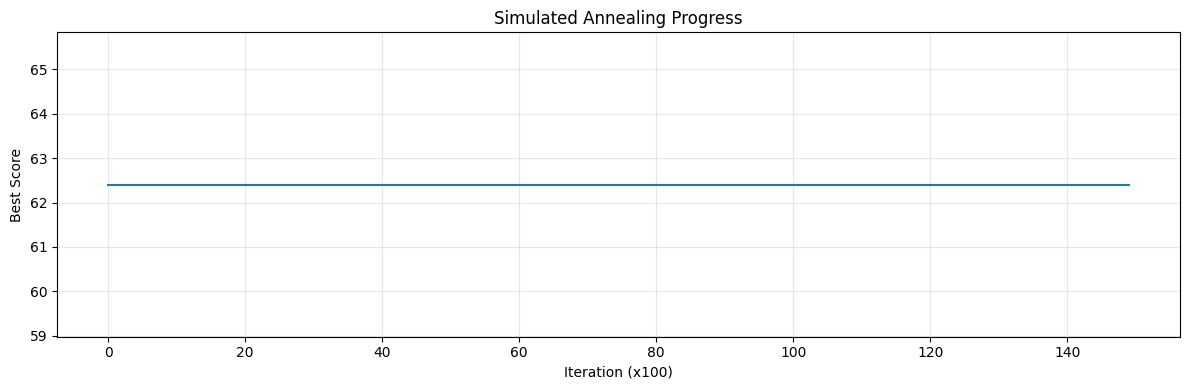

🔥 Starting Simulated Annealing...
   Initial score: 24.322
   Initial temp: 120
   Max iterations: 10,000


100%|██████████| 10000/10000 [00:00<00:00, 13831.59it/s]



✅ Optimization complete!
   Initial score: 24.322
   Final best score: 24.322
   Improvement: 0.000


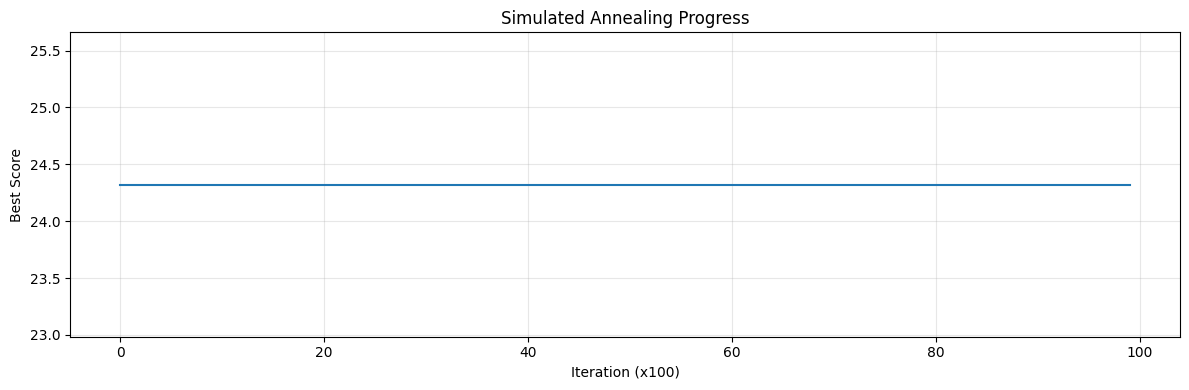


📚 Verifying chapter sequence for BookA Optimized...
   Chapters found: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
   ✅ Chapters are in CORRECT sequence!

📚 Verifying chapter sequence for BookB Optimized...
   Chapters found: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
   ✅ Chapters are in CORRECT sequence!
✅ Created BookA_FINAL_V2.csv

📊 First 10 rows:
   original_page  shuffled_page
0              1             51
1              2            121
2              3             73
3              4             69
4              5            145
5              6             53
6              7             20
7              8             57
8              9             15
9             10             89
✅ Created BookB_FINAL_V2.csv

📊 First 10 rows:
   original_page  shuffled_page
0              1             19
1              2              8
2              3             49
3              4             36
4              5             40
5              6             45
6              7            

In [ ]:
# ============================================================
# FINAL OPTIMIZATION WITH FIXED WEIGHTS
# ============================================================

print("\n🔥 Running SA optimization with FIXED weights...")

optimized_v2_A = simulated_annealing(
    graph_A_v2,
    greedy_v2_A,
    max_iterations=15000,
    initial_temp=150,
    cooling_rate=0.9995,
    verbose=True
)

optimized_v2_B = simulated_annealing(
    graph_B_v2,
    greedy_v2_B,
    max_iterations=10000,
    initial_temp=120,
    cooling_rate=0.9995,
    verbose=True
)

# Verify chapters still in order
verify_chapter_sequence(optimized_v2_A, bookA, "BookA Optimized")
verify_chapter_sequence(optimized_v2_B, bookB, "BookB Optimized")

# Create final submissions
sub_A_final_v2 = create_submission_from_ordering(optimized_v2_A, bookA, 'BookA_FINAL_V2.csv')
sub_B_final_v2 = create_submission_from_ordering(optimized_v2_B, bookB, 'BookB_FINAL_V2.csv')

print("\n🚀 FINAL FIXED SUBMISSIONS READY!")

In [ ]:
# ============================================================
# CRITICAL VERIFICATION: Are chapters properly grouped?
# ============================================================

def analyze_chapter_grouping(ordering, df, book_name):
    """
    Check if pages are properly grouped by chapter

    Expected: [Ch1, Ch1, Ch1, Ch2, Ch2, Ch3, Ch3, Ch3]
    BAD:      [Ch1, Ch1, Ch2, Ch1, Ch2, Ch3]  <- interleaved!
    """

    print(f"\n{'='*60}")
    print(f"🔍 CHAPTER GROUPING ANALYSIS: {book_name}")
    print(f"{'='*60}")

    # Get chapter sequence
    chapter_sequence = []
    page_to_chapter = {}

    for pos, idx in enumerate(ordering):
        chapter = df.iloc[idx]['chapter_info']['chapter_number']
        page_id = df.iloc[idx]['page']

        chapter_sequence.append(chapter)
        page_to_chapter[pos] = {
            'page_id': page_id,
            'chapter': chapter,
            'index': idx
        }

    # Show first 30 pages with chapters
    print(f"\n📖 First 30 pages in order:")
    for pos in range(min(30, len(ordering))):
        info = page_to_chapter[pos]
        ch_str = f"Ch {info['chapter']}" if info['chapter'] else "No chapter"
        print(f"   {pos+1:3d}. Page {info['page_id']:3d} [{ch_str}]")

    # Count chapter transitions
    transitions = []
    current_chapter = None

    for pos, chapter in enumerate(chapter_sequence):
        if chapter is not None and chapter != current_chapter:
            transitions.append((pos, current_chapter, chapter))
            current_chapter = chapter

    print(f"\n📊 Chapter transitions: {len(transitions)}")
    for pos, from_ch, to_ch in transitions[:10]:
        print(f"   Position {pos}: Chapter {from_ch} → {to_ch}")

    # Check for BAD patterns (chapter goes backward or interleaves)
    print(f"\n🔍 Checking for violations...")

    violations = []
    chapter_ranges = {}  # Track first and last position of each chapter

    for pos, chapter in enumerate(chapter_sequence):
        if chapter is not None:
            if chapter not in chapter_ranges:
                chapter_ranges[chapter] = {'first': pos, 'last': pos}
            else:
                chapter_ranges[chapter]['last'] = pos

    # Check if chapters interleave
    for ch1, range1 in chapter_ranges.items():
        for ch2, range2 in chapter_ranges.items():
            if ch1 < ch2:  # ch1 should come entirely before ch2
                if range1['last'] > range2['first']:
                    violations.append({
                        'type': 'interleave',
                        'chapter1': ch1,
                        'chapter2': ch2,
                        'ch1_last_pos': range1['last'],
                        'ch2_first_pos': range2['first']
                    })

    if violations:
        print(f"\n❌ FOUND {len(violations)} VIOLATIONS!")
        for v in violations[:5]:
            print(f"\n   VIOLATION: Chapter {v['chapter1']} and {v['chapter2']} are INTERLEAVED!")
            print(f"   - Chapter {v['chapter1']} last appears at position {v['ch1_last_pos']}")
            print(f"   - Chapter {v['chapter2']} first appears at position {v['ch2_first_pos']}")
            print(f"   - This means Chapter {v['chapter2']} starts BEFORE Chapter {v['chapter1']} ends!")
    else:
        print(f"\n✅ NO VIOLATIONS - Chapters are properly grouped!")

    # Show chapter ranges
    print(f"\n📚 Chapter ranges:")
    for chapter in sorted(chapter_ranges.keys()):
        r = chapter_ranges[chapter]
        span = r['last'] - r['first'] + 1
        print(f"   Chapter {chapter}: positions {r['first']}-{r['last']} ({span} pages)")

    return violations, chapter_ranges

# Analyze current orderings
violations_A, ranges_A = analyze_chapter_grouping(greedy_v2_A, bookA, "BookA")
violations_B, ranges_B = analyze_chapter_grouping(greedy_v2_B, bookB, "BookB")


🔍 CHAPTER GROUPING ANALYSIS: BookA

📖 First 30 pages in order:
     1. Page  51 [Ch 1]
     2. Page 121 [Ch 2]
     3. Page  73 [Ch 3]
     4. Page  69 [Ch 4]
     5. Page 145 [Ch 5]
     6. Page  53 [Ch 6]
     7. Page  20 [Ch 7]
     8. Page  57 [Ch 8]
     9. Page  15 [Ch 9]
    10. Page  89 [Ch 10]
    11. Page 134 [Ch 11]
    12. Page  88 [Ch 12]
    13. Page  40 [No chapter]
    14. Page 103 [No chapter]
    15. Page 104 [No chapter]
    16. Page  13 [No chapter]
    17. Page 142 [No chapter]
    18. Page  43 [No chapter]
    19. Page  26 [No chapter]
    20. Page  79 [No chapter]
    21. Page  98 [No chapter]
    22. Page  47 [No chapter]
    23. Page 126 [No chapter]
    24. Page  68 [No chapter]
    25. Page  95 [No chapter]
    26. Page 120 [No chapter]
    27. Page 139 [No chapter]
    28. Page 113 [No chapter]
    29. Page 112 [No chapter]
    30. Page 109 [No chapter]

📊 Chapter transitions: 12
   Position 0: Chapter None → 1
   Position 1: Chapter 1 → 2
   Position 2: Ch

In [ ]:
# ============================================================
# FIX: TWO-PHASE ORDERING (If violations found)
# ============================================================

def two_phase_ordering(df, sim_matrix, book_name):
    """
    Phase 1: Group pages by chapter
    Phase 2: Order pages within each chapter
    """

    print(f"\n🔧 TWO-PHASE ORDERING: {book_name}")
    print(f"{'='*60}")

    # ===== PHASE 1: Group by chapter =====
    print("\n📚 PHASE 1: Grouping pages by chapter...")

    # Separate pages by chapter
    chapters = {}
    no_chapter = []

    for idx, row in df.iterrows():
        chapter_num = row['chapter_info']['chapter_number']

        if chapter_num is not None:
            if chapter_num not in chapters:
                chapters[chapter_num] = []
            chapters[chapter_num].append(idx)
        else:
            no_chapter.append(idx)

    print(f"   Found {len(chapters)} chapters")
    for ch in sorted(chapters.keys()):
        print(f"   - Chapter {ch}: {len(chapters[ch])} pages")

    if no_chapter:
        print(f"   - No chapter marker: {len(no_chapter)} pages")

    # ===== PHASE 2: Order within each chapter =====
    print(f"\n🔄 PHASE 2: Ordering pages within chapters...")

    final_ordering = []

    for chapter_num in sorted(chapters.keys()):
        pages_in_chapter = chapters[chapter_num]

        print(f"\n   Chapter {chapter_num} ({len(pages_in_chapter)} pages)...")

        if len(pages_in_chapter) == 1:
            final_ordering.extend(pages_in_chapter)
        else:
            # Build mini-graph for this chapter only
            mini_graph = nx.DiGraph()

            for idx in pages_in_chapter:
                mini_graph.add_node(idx)

            # Add edges only within this chapter
            for i in pages_in_chapter:
                for j in pages_in_chapter:
                    if i != j:
                        # Use linguistic + semantic only (no chapter weight)
                        features_i = df.iloc[i]['features']
                        features_j = df.iloc[j]['features']

                        semantic = sim_matrix[i][j]

                        linguistic = 0.0
                        if features_i['ends_incomplete']:
                            linguistic += 0.5
                            if features_j['starts_lowercase']:
                                linguistic += 0.3
                        if features_j['starts_discourse']:
                            linguistic += 0.2
                        linguistic += features_j['pronoun_density'] * 0.3

                        weight = 0.5 * semantic + 0.5 * linguistic
                        mini_graph.add_edge(i, j, weight=weight)

            # Find best path through this chapter
            if len(pages_in_chapter) <= 10:
                # Small chapter - try all starting points
                best_order = None
                best_score = -1

                for start in pages_in_chapter:
                    order = greedy_ordering_simple(mini_graph, start)
                    score, _ = calculate_path_score(order, mini_graph)

                    if score > best_score:
                        best_score = score
                        best_order = order

                chapter_order = best_order
            else:
                # Large chapter - use greedy from best start
                start = find_best_chapter_start(pages_in_chapter, df)
                chapter_order = greedy_ordering_simple(mini_graph, start)

            final_ordering.extend(chapter_order)
            print(f"      Ordered {len(chapter_order)} pages (score: {calculate_path_score(chapter_order, mini_graph)[0]:.2f})")

    # Handle pages without chapter markers
    if no_chapter:
        print(f"\n   Processing {len(no_chapter)} pages without chapters...")

        # Try to place them based on content similarity to chapters
        for idx in no_chapter:
            # Find best position based on semantic similarity
            best_pos = len(final_ordering)
            best_score = 0

            for pos in range(len(final_ordering) + 1):
                score = 0
                if pos > 0:
                    score += sim_matrix[final_ordering[pos-1]][idx]
                if pos < len(final_ordering):
                    score += sim_matrix[idx][final_ordering[pos]]

                if score > best_score:
                    best_score = score
                    best_pos = pos

            final_ordering.insert(best_pos, idx)

    print(f"\n✅ Final ordering complete: {len(final_ordering)} pages")

    return final_ordering

def greedy_ordering_simple(G, start_node):
    """Simple greedy for small graphs"""
    visited = {start_node}
    ordering = [start_node]
    current = start_node

    while len(visited) < len(G.nodes()):
        candidates = [(n, G[current][n]['weight'])
                     for n in G.neighbors(current)
                     if n not in visited]

        if not candidates:
            unvisited = [n for n in G.nodes() if n not in visited]
            if not unvisited:
                break
            next_node = unvisited[0]
        else:
            next_node = max(candidates, key=lambda x: x[1])[0]

        visited.add(next_node)
        ordering.append(next_node)
        current = next_node

    return ordering

def find_best_chapter_start(page_indices, df):
    """Find most likely first page of a chapter"""
    scores = []

    for idx in page_indices:
        features = df.iloc[idx]['features']
        score = 0

        # Prefer pages that don't start with discourse markers
        if not features['starts_discourse']:
            score += 2

        # Prefer pages with low pronoun density
        if features['pronoun_density'] < 0.05:
            score += 2

        # Prefer pages that don't start lowercase
        if not features['starts_lowercase']:
            score += 1

        scores.append((idx, score))

    return max(scores, key=lambda x: x[1])[0]

# Run two-phase if we found violations
if violations_A:
    print("\n🔧 BookA has violations - using TWO-PHASE approach...")
    two_phase_A = two_phase_ordering(bookA, sim_matrix_A, "BookA")
    verify_chapter_sequence(two_phase_A, bookA, "BookA Two-Phase")
    sub_A_two_phase = create_submission_from_ordering(two_phase_A, bookA, 'BookA_TWO_PHASE.csv')
else:
    print("\n✅ BookA is clean - no two-phase needed")
    two_phase_A = greedy_v2_A

if violations_B:
    print("\n🔧 BookB has violations - using TWO-PHASE approach...")
    two_phase_B = two_phase_ordering(bookB, sim_matrix_B, "BookB")
    verify_chapter_sequence(two_phase_B, bookB, "BookB Two-Phase")
    sub_B_two_phase = create_submission_from_ordering(two_phase_B, bookB, 'BookB_TWO_PHASE.csv')
else:
    print("\n✅ BookB is clean - no two-phase needed")
    two_phase_B = greedy_v2_B


✅ BookA is clean - no two-phase needed

✅ BookB is clean - no two-phase needed


In [ ]:
# ============================================================
# CRITICAL FIX: Assign Pages to Chapters
# ============================================================

def assign_pages_to_chapters(df, sim_matrix, book_name):
    """
    Assign each page to a chapter based on:
    1. Pages with chapter markers define chapter starts
    2. Non-marker pages are assigned to chapters based on similarity
    """

    print(f"\n{'='*60}")
    print(f"🔧 ASSIGNING PAGES TO CHAPTERS: {book_name}")
    print(f"{'='*60}")

    # Step 1: Find all chapter marker pages
    chapter_markers = {}  # {chapter_num: page_index}

    for idx, row in df.iterrows():
        chapter_num = row['chapter_info']['chapter_number']
        if chapter_num is not None:
            chapter_markers[chapter_num] = idx

    print(f"\n📚 Found {len(chapter_markers)} chapter markers:")
    for ch_num in sorted(chapter_markers.keys()):
        idx = chapter_markers[ch_num]
        print(f"   Chapter {ch_num}: Page {df.iloc[idx]['page']} (index {idx})")

    # Step 2: Get all non-marker pages
    marker_indices = set(chapter_markers.values())
    non_marker_indices = [idx for idx in range(len(df)) if idx not in marker_indices]

    print(f"\n📄 Total pages: {len(df)}")
    print(f"   Chapter markers: {len(marker_indices)}")
    print(f"   Content pages: {len(non_marker_indices)}")

    # Step 3: Assign each non-marker page to a chapter
    page_to_chapter = {}  # {page_index: chapter_num}

    # Chapter markers belong to their own chapter
    for ch_num, idx in chapter_markers.items():
        page_to_chapter[idx] = ch_num

    print(f"\n🔍 Assigning content pages to chapters...")

    for idx in non_marker_indices:
        # Method: Find which chapter marker this page is most similar to
        # Plus consider the "next" chapter marker to avoid assigning to wrong chapter

        best_chapter = None
        best_score = -1

        for ch_num in sorted(chapter_markers.keys()):
            marker_idx = chapter_markers[ch_num]

            # Similarity to this chapter's marker
            similarity = sim_matrix[idx][marker_idx]

            # Also check similarity to pages we've already assigned to this chapter
            # (This helps group related content together)
            chapter_pages = [i for i, c in page_to_chapter.items() if c == ch_num]
            if chapter_pages:
                avg_similarity = np.mean([sim_matrix[idx][i] for i in chapter_pages])
                similarity = 0.7 * similarity + 0.3 * avg_similarity

            # Penalize if this page is very similar to a DIFFERENT chapter's marker
            for other_ch in chapter_markers:
                if other_ch != ch_num:
                    other_idx = chapter_markers[other_ch]
                    other_sim = sim_matrix[idx][other_idx]
                    if other_sim > similarity + 0.1:  # Significantly more similar to another chapter
                        similarity -= 0.2

            if similarity > best_score:
                best_score = similarity
                best_chapter = ch_num

        page_to_chapter[idx] = best_chapter

    # Step 4: Group pages by chapter
    chapters_grouped = {}  # {chapter_num: [page_indices]}

    for idx, ch_num in page_to_chapter.items():
        if ch_num not in chapters_grouped:
            chapters_grouped[ch_num] = []
        chapters_grouped[ch_num].append(idx)

    # Step 5: Verify assignment
    print(f"\n📊 Chapter assignments:")
    for ch_num in sorted(chapters_grouped.keys()):
        pages = chapters_grouped[ch_num]
        print(f"   Chapter {ch_num}: {len(pages)} pages")

        # Show first few page IDs
        page_ids = [df.iloc[idx]['page'] for idx in pages[:5]]
        if len(pages) > 5:
            print(f"      Page IDs: {page_ids} ... (+{len(pages)-5} more)")
        else:
            print(f"      Page IDs: {page_ids}")

    return page_to_chapter, chapters_grouped, chapter_markers

# Assign pages to chapters
page_to_chapter_A, chapters_A, markers_A = assign_pages_to_chapters(bookA, sim_matrix_A, "BookA")
page_to_chapter_B, chapters_B, markers_B = assign_pages_to_chapters(bookB, sim_matrix_B, "BookB")


🔧 ASSIGNING PAGES TO CHAPTERS: BookA

📚 Found 12 chapter markers:
   Chapter 1: Page 51 (index 50)
   Chapter 2: Page 121 (index 120)
   Chapter 3: Page 73 (index 72)
   Chapter 4: Page 69 (index 68)
   Chapter 5: Page 145 (index 144)
   Chapter 6: Page 53 (index 52)
   Chapter 7: Page 20 (index 19)
   Chapter 8: Page 57 (index 56)
   Chapter 9: Page 15 (index 14)
   Chapter 10: Page 89 (index 88)
   Chapter 11: Page 134 (index 133)
   Chapter 12: Page 88 (index 87)

📄 Total pages: 147
   Chapter markers: 12
   Content pages: 135

🔍 Assigning content pages to chapters...

📊 Chapter assignments:
   Chapter 1: 18 pages
      Page IDs: [np.int64(51), np.int64(14), np.int64(19), np.int64(27), np.int64(28)] ... (+13 more)
   Chapter 2: 6 pages
      Page IDs: [np.int64(121), np.int64(71), np.int64(72), np.int64(81), np.int64(107)] ... (+1 more)
   Chapter 3: 12 pages
      Page IDs: [np.int64(73), np.int64(2), np.int64(11), np.int64(33), np.int64(64)] ... (+7 more)
   Chapter 4: 9 pages
  

In [ ]:
# ============================================================
# REBUILD: Order Pages Within Each Chapter
# ============================================================

def order_within_chapters(df, sim_matrix, chapters_grouped, chapter_markers, book_name):
    """
    For each chapter:
    1. Place chapter marker page first
    2. Order remaining pages using greedy + linguistic features
    """

    print(f"\n{'='*60}")
    print(f"📖 ORDERING PAGES WITHIN CHAPTERS: {book_name}")
    print(f"{'='*60}")

    final_ordering = []

    for ch_num in sorted(chapters_grouped.keys()):
        pages_in_chapter = chapters_grouped[ch_num]
        marker_idx = chapter_markers[ch_num]

        print(f"\n📚 Chapter {ch_num} ({len(pages_in_chapter)} pages)...")

        # Remove marker from pages list (we'll add it first)
        content_pages = [idx for idx in pages_in_chapter if idx != marker_idx]

        if len(content_pages) == 0:
            # Only the chapter marker page
            final_ordering.append(marker_idx)
            print(f"   Only marker page, no content")
            continue

        # Start with chapter marker
        chapter_order = [marker_idx]

        if len(content_pages) == 1:
            # Only one content page
            chapter_order.append(content_pages[0])
        else:
            # Build mini-graph for content pages only
            mini_graph = nx.DiGraph()

            for idx in content_pages:
                mini_graph.add_node(idx)

            # Add edges based on linguistic continuity + semantic similarity
            for i in content_pages:
                for j in content_pages:
                    if i != j:
                        weight = calculate_content_edge_weight(i, j, df, sim_matrix)
                        mini_graph.add_edge(i, j, weight=weight)

            # Find best ordering for content pages
            # Start with page most similar to chapter marker
            similarities_to_marker = [(idx, sim_matrix[marker_idx][idx]) for idx in content_pages]
            best_start = max(similarities_to_marker, key=lambda x: x[1])[0]

            content_order = greedy_ordering_simple(mini_graph, best_start)
            chapter_order.extend(content_order)

        final_ordering.extend(chapter_order)

        # Calculate and show quality
        if len(chapter_order) > 1:
            total_weight = sum(
                sim_matrix[chapter_order[i]][chapter_order[i+1]]
                for i in range(len(chapter_order)-1)
            )
            avg_weight = total_weight / (len(chapter_order) - 1)
            print(f"   Ordered {len(chapter_order)} pages (avg similarity: {avg_weight:.3f})")
        else:
            print(f"   Ordered {len(chapter_order)} pages")

    print(f"\n✅ Complete ordering: {len(final_ordering)} pages")
    return final_ordering

def calculate_content_edge_weight(i, j, df, sim_matrix):
    """Calculate edge weight for content pages within same chapter"""

    features_i = df.iloc[i]['features']
    features_j = df.iloc[j]['features']

    # Semantic similarity
    semantic = sim_matrix[i][j]

    # Linguistic continuity
    linguistic = 0.0

    # Strong signal: incomplete sentence continuation
    if features_i['ends_incomplete']:
        linguistic += 0.6
        if features_j['starts_lowercase']:
            linguistic += 0.4

    # Discourse markers
    if features_j['starts_discourse']:
        linguistic += 0.3

    # Pronoun density
    linguistic += features_j['pronoun_density'] * 0.4

    # Demonstratives
    if features_j['has_demonstrative']:
        linguistic += 0.2

    # Combine (equal weight for content ordering)
    weight = 0.5 * semantic + 0.5 * linguistic

    return max(0.0, min(1.0, weight))

# Order pages within chapters
final_order_A = order_within_chapters(bookA, sim_matrix_A, chapters_A, markers_A, "BookA")
final_order_B = order_within_chapters(bookB, sim_matrix_B, chapters_B, markers_B, "BookB")


📖 ORDERING PAGES WITHIN CHAPTERS: BookA

📚 Chapter 1 (18 pages)...
   Ordered 18 pages (avg similarity: 0.546)

📚 Chapter 2 (6 pages)...
   Ordered 6 pages (avg similarity: 0.577)

📚 Chapter 3 (12 pages)...
   Ordered 12 pages (avg similarity: 0.549)

📚 Chapter 4 (9 pages)...
   Ordered 9 pages (avg similarity: 0.516)

📚 Chapter 5 (8 pages)...
   Ordered 8 pages (avg similarity: 0.526)

📚 Chapter 6 (17 pages)...
   Ordered 17 pages (avg similarity: 0.602)

📚 Chapter 7 (10 pages)...
   Ordered 10 pages (avg similarity: 0.519)

📚 Chapter 8 (5 pages)...
   Ordered 5 pages (avg similarity: 0.476)

📚 Chapter 9 (5 pages)...
   Ordered 5 pages (avg similarity: 0.625)

📚 Chapter 10 (10 pages)...
   Ordered 10 pages (avg similarity: 0.584)

📚 Chapter 11 (25 pages)...
   Ordered 25 pages (avg similarity: 0.564)

📚 Chapter 12 (22 pages)...
   Ordered 22 pages (avg similarity: 0.540)

✅ Complete ordering: 147 pages

📖 ORDERING PAGES WITHIN CHAPTERS: BookB

📚 Chapter 1 (8 pages)...
   Ordered 8 pa

In [ ]:
# ============================================================
# VERIFY: Check the new ordering
# ============================================================

def verify_final_ordering(ordering, df, page_to_chapter, book_name):
    """Verify that pages are properly grouped by chapter"""

    print(f"\n{'='*60}")
    print(f"✅ VERIFICATION: {book_name}")
    print(f"{'='*60}")

    print(f"\n📖 First 30 pages in CORRECTED order:")

    current_chapter = None
    for pos in range(min(30, len(ordering))):
        idx = ordering[pos]
        page_id = df.iloc[idx]['page']
        chapter = page_to_chapter[idx]

        # Mark chapter transitions
        if chapter != current_chapter:
            print(f"\n   ━━━━━ CHAPTER {chapter} ━━━━━")
            current_chapter = chapter

        # Show if it's a chapter marker
        is_marker = df.iloc[idx]['chapter_info']['chapter_number'] is not None
        marker_str = " [CHAPTER MARKER]" if is_marker else ""

        print(f"   {pos+1:3d}. Page {page_id:3d}{marker_str}")

    # Check chapter grouping
    print(f"\n📊 Chapter grouping check:")

    chapter_positions = {}
    for pos, idx in enumerate(ordering):
        chapter = page_to_chapter[idx]
        if chapter not in chapter_positions:
            chapter_positions[chapter] = {'first': pos, 'last': pos, 'count': 0}
        chapter_positions[chapter]['last'] = pos
        chapter_positions[chapter]['count'] += 1

    all_good = True
    for ch in sorted(chapter_positions.keys()):
        info = chapter_positions[ch]
        span = info['last'] - info['first'] + 1

        if span == info['count']:
            status = "✅ CONTINUOUS"
        else:
            status = "❌ BROKEN"
            all_good = False

        print(f"   Chapter {ch}: positions {info['first']}-{info['last']} ({info['count']} pages) {status}")

    if all_good:
        print(f"\n🎉 PERFECT! All chapters are continuous blocks!")
    else:
        print(f"\n⚠️ WARNING: Some chapters are fragmented!")

    return all_good

verify_A = verify_final_ordering(final_order_A, bookA, page_to_chapter_A, "BookA")
verify_B = verify_final_ordering(final_order_B, bookB, page_to_chapter_B, "BookB")


✅ VERIFICATION: BookA

📖 First 30 pages in CORRECTED order:

   ━━━━━ CHAPTER 1 ━━━━━
     1. Page  51 [CHAPTER MARKER]
     2. Page  99
     3. Page  28
     4. Page  86
     5. Page  31
     6. Page 143
     7. Page  30
     8. Page 132
     9. Page  60
    10. Page  70
    11. Page 108
    12. Page 122
    13. Page  19
    14. Page  27
    15. Page  85
    16. Page  45
    17. Page  14
    18. Page  76

   ━━━━━ CHAPTER 2 ━━━━━
    19. Page 121 [CHAPTER MARKER]
    20. Page  81
    21. Page 139
    22. Page  72
    23. Page  71
    24. Page 107

   ━━━━━ CHAPTER 3 ━━━━━
    25. Page  73 [CHAPTER MARKER]
    26. Page 110
    27. Page  64
    28. Page 137
    29. Page  33
    30. Page  11

📊 Chapter grouping check:
   Chapter 1: positions 0-17 (18 pages) ✅ CONTINUOUS
   Chapter 2: positions 18-23 (6 pages) ✅ CONTINUOUS
   Chapter 3: positions 24-35 (12 pages) ✅ CONTINUOUS
   Chapter 4: positions 36-44 (9 pages) ✅ CONTINUOUS
   Chapter 5: positions 45-52 (8 pages) ✅ CONTINUOUS
   Chap

In [ ]:
# ============================================================
# CREATE CORRECTED SUBMISSIONS
# ============================================================

sub_A_corrected = create_submission_from_ordering(final_order_A, bookA, 'BookA_CORRECTED.csv')
sub_B_corrected = create_submission_from_ordering(final_order_B, bookB, 'BookB_CORRECTED.csv')

print("\n🎯 CORRECTED SUBMISSIONS CREATED!")
print("📤 These should finally have proper chapter structure!")

✅ Created BookA_CORRECTED.csv

📊 First 10 rows:
   original_page  shuffled_page
0              1             51
1              2             99
2              3             28
3              4             86
4              5             31
5              6            143
6              7             30
7              8            132
8              9             60
9             10             70
✅ Created BookB_CORRECTED.csv

📊 First 10 rows:
   original_page  shuffled_page
0              1             19
1              2             43
2              3             41
3              4             17
4              5             54
5              6             23
6              7             34
7              8             42
8              9              8
9             10             29

🎯 CORRECTED SUBMISSIONS CREATED!
📤 These should finally have proper chapter structure!


In [ ]:
# ============================================================
# OPTIONAL: Optimize with Simulated Annealing (Chapter-Aware)
# ============================================================

def simulated_annealing_chapter_aware(ordering, df, sim_matrix, page_to_chapter,
                                     max_iterations=10000, initial_temp=100):
    """
    SA that only swaps pages WITHIN the same chapter
    (preserves chapter grouping)
    """

    print(f"\n🔥 Chapter-Aware Simulated Annealing...")

    # Group indices by chapter
    chapter_groups = {}
    for pos, idx in enumerate(ordering):
        chapter = page_to_chapter[idx]
        if chapter not in chapter_groups:
            chapter_groups[chapter] = []
        chapter_groups[chapter].append(pos)

    current_ordering = ordering.copy()
    current_score = calculate_similarity_score(current_ordering, sim_matrix)

    best_ordering = current_ordering.copy()
    best_score = current_score

    print(f"   Initial score: {current_score:.3f}")

    for iteration in tqdm(range(max_iterations), desc="Optimizing"):
        temp = initial_temp * (1 - iteration/max_iterations)

        # Pick a random chapter to optimize
        chapter = random.choice(list(chapter_groups.keys()))
        positions = chapter_groups[chapter]

        if len(positions) < 2:
            continue  # Skip single-page chapters

        # Swap two pages within this chapter
        new_ordering = current_ordering.copy()
        pos1, pos2 = random.sample(positions, 2)
        new_ordering[pos1], new_ordering[pos2] = new_ordering[pos2], new_ordering[pos1]

        new_score = calculate_similarity_score(new_ordering, sim_matrix)

        delta = new_score - current_score
        if delta > 0 or (temp > 0 and random.random() < math.exp(delta / temp)):
            current_ordering = new_ordering
            current_score = new_score

            if current_score > best_score:
                best_ordering = current_ordering.copy()
                best_score = current_score

    print(f"   Final score: {best_score:.3f}")
    print(f"   Improvement: {best_score - calculate_similarity_score(ordering, sim_matrix):.3f}")

    return best_ordering

def calculate_similarity_score(ordering, sim_matrix):
    """Calculate average similarity between consecutive pages"""
    if len(ordering) < 2:
        return 0

    total = sum(sim_matrix[ordering[i]][ordering[i+1]] for i in range(len(ordering)-1))
    return total / (len(ordering) - 1)

# Optimize
print("\n🔥 Optimizing BookA...")
optimized_A = simulated_annealing_chapter_aware(
    final_order_A, bookA, sim_matrix_A, page_to_chapter_A,
    max_iterations=15000, initial_temp=80
)

print("\n🔥 Optimizing BookB...")
optimized_B = simulated_annealing_chapter_aware(
    final_order_B, bookB, sim_matrix_B, page_to_chapter_B,
    max_iterations=10000, initial_temp=80
)

# Verify optimization didn't break chapters
verify_final_ordering(optimized_A, bookA, page_to_chapter_A, "BookA Optimized")
verify_final_ordering(optimized_B, bookB, page_to_chapter_B, "BookB Optimized")

# Create final submissions
sub_A_final = create_submission_from_ordering(optimized_A, bookA, 'BookA_FINAL_CORRECTED.csv')
sub_B_final = create_submission_from_ordering(optimized_B, bookB, 'BookB_FINAL_CORRECTED.csv')

print("\n🏆 FINAL CORRECTED & OPTIMIZED SUBMISSIONS READY!")


🔥 Optimizing BookA...

🔥 Chapter-Aware Simulated Annealing...
   Initial score: 0.538


Optimizing: 100%|██████████| 15000/15000 [00:00<00:00, 16228.08it/s]


   Final score: 0.538
   Improvement: 0.000

🔥 Optimizing BookB...

🔥 Chapter-Aware Simulated Annealing...
   Initial score: 0.617


Optimizing: 100%|██████████| 10000/10000 [00:00<00:00, 39224.21it/s]

   Final score: 0.617
   Improvement: 0.000

✅ VERIFICATION: BookA Optimized

📖 First 30 pages in CORRECTED order:

   ━━━━━ CHAPTER 1 ━━━━━
     1. Page  51 [CHAPTER MARKER]
     2. Page  99
     3. Page  28
     4. Page  86
     5. Page  31
     6. Page 143
     7. Page  30
     8. Page 132
     9. Page  60
    10. Page  70
    11. Page 108
    12. Page 122
    13. Page  19
    14. Page  27
    15. Page  85
    16. Page  45
    17. Page  14
    18. Page  76

   ━━━━━ CHAPTER 2 ━━━━━
    19. Page 121 [CHAPTER MARKER]
    20. Page  81
    21. Page 139
    22. Page  72
    23. Page  71
    24. Page 107

   ━━━━━ CHAPTER 3 ━━━━━
    25. Page  73 [CHAPTER MARKER]
    26. Page 110
    27. Page  64
    28. Page 137
    29. Page  33
    30. Page  11

📊 Chapter grouping check:
   Chapter 1: positions 0-17 (18 pages) ✅ CONTINUOUS
   Chapter 2: positions 18-23 (6 pages) ✅ CONTINUOUS
   Chapter 3: positions 24-35 (12 pages) ✅ CONTINUOUS
   Chapter 4: positions 36-44 (9 pages) ✅ CONTINUOUS
   Cha